<a href="https://colab.research.google.com/github/glafica/GL_Data_Lab/blob/main/Machine_Learning/Trabajo_Integrador/Entrega_2026_TPFinal_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🤖 ENTREGA FINAL DEL TRABAJO INTEGRADOR - MACHINE LEARNING**

**Alumno:** Gustavo Lafica

**Comisión:** 26140

**Profesor:** Ariel Palazzesi

**Mes Año:** Julio 2026

---
# **📢 Descripción del Dataset:**
---

El Dataset que elegí es el de "Robos y recuperos de autos" proporcionado por el
Ministerio de Justicia, Subsecretaría de Asuntos Registrales, Dirección Nacional de los Registros Nacionales de la Propiedad del Automotor y Créditos Prendarios.
<br>
<br>
El link a la pagina web es 👉  https://www.datos.gob.ar/dataset/justicia-robos-recuperos-autos   
<br>
Este Dataset se compone de **99** archivos ".csv" que contienen información sobre denuncias de Robo y Recuperación de Automoviles en todo el País.
<br>

Para poder trabajar con un solo archivo, consolidé los 99 archivos descargados desde **01/2018** a **03/2026**.
<br>
Todos los archivos contienen **25 columnas**.

&nbsp;&nbsp;&nbsp;▶&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;El consolidado se llama: ***"robos_recuperos_autos.csv".***
<br>

 Para evitar tener que entregar el trabajo junto con los 99 archivos originales, este proceso lo muestro, mas abajo, en los prints de pantalla y al mismo tiempo dejo comentado el código utilizado.
<br>

De modo que el trabajo de Pre-Entrega lo hago a partir de la importacion del archivo ***"robos_recuperos_autos.csv"***.

---
# **❓Objetivo del Proyecto:**

El objetivo de este trabajo consiste en desarrollar un modelo de clasificación capaz de identificar si un registro corresponde a un trámite de recupero o a un trámite de denuncia, utilizando variables descriptivas del vehículo, su titular y el contexto geográfico y temporal.

Debido a que el dataset no contiene un identificador que permita vincular una denuncia con un recupero posterior del mismo vehículo, este modelo no predice el recupero futuro de un vehículo denunciado, sino que clasifica el tipo de registro presente en la base de datos.

# 📋**NOTA:**

Mas abajo muestro con capturas de pantallas, el procedimiento que usé para generar el archivo llamado: "robos_recuperos_autos.csv" a partir de la consolidación de los 99 archivos descargados.

Este archivo: "robos_recuperos_autos.csv" es el que se debe cargar para iniciar el proyecto.

⌛Considerar que al tratarse de mas de 300.000 filas, Colab, tarda unos segundos en cargarlo.

(Print #01)

## *Estos son parte de los 99 archivos descargados* 👇

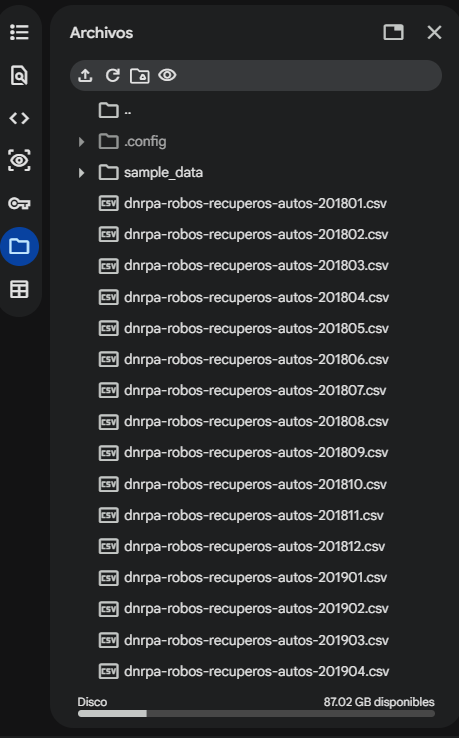


(Print #02)

## *Consolido los 99 archivos* 👇


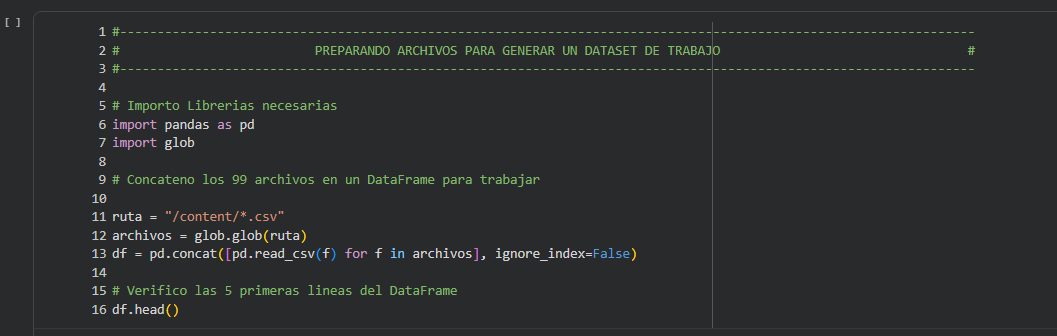

(Print #03)

## *Este es el resultado del proceso de consolidación* 👇

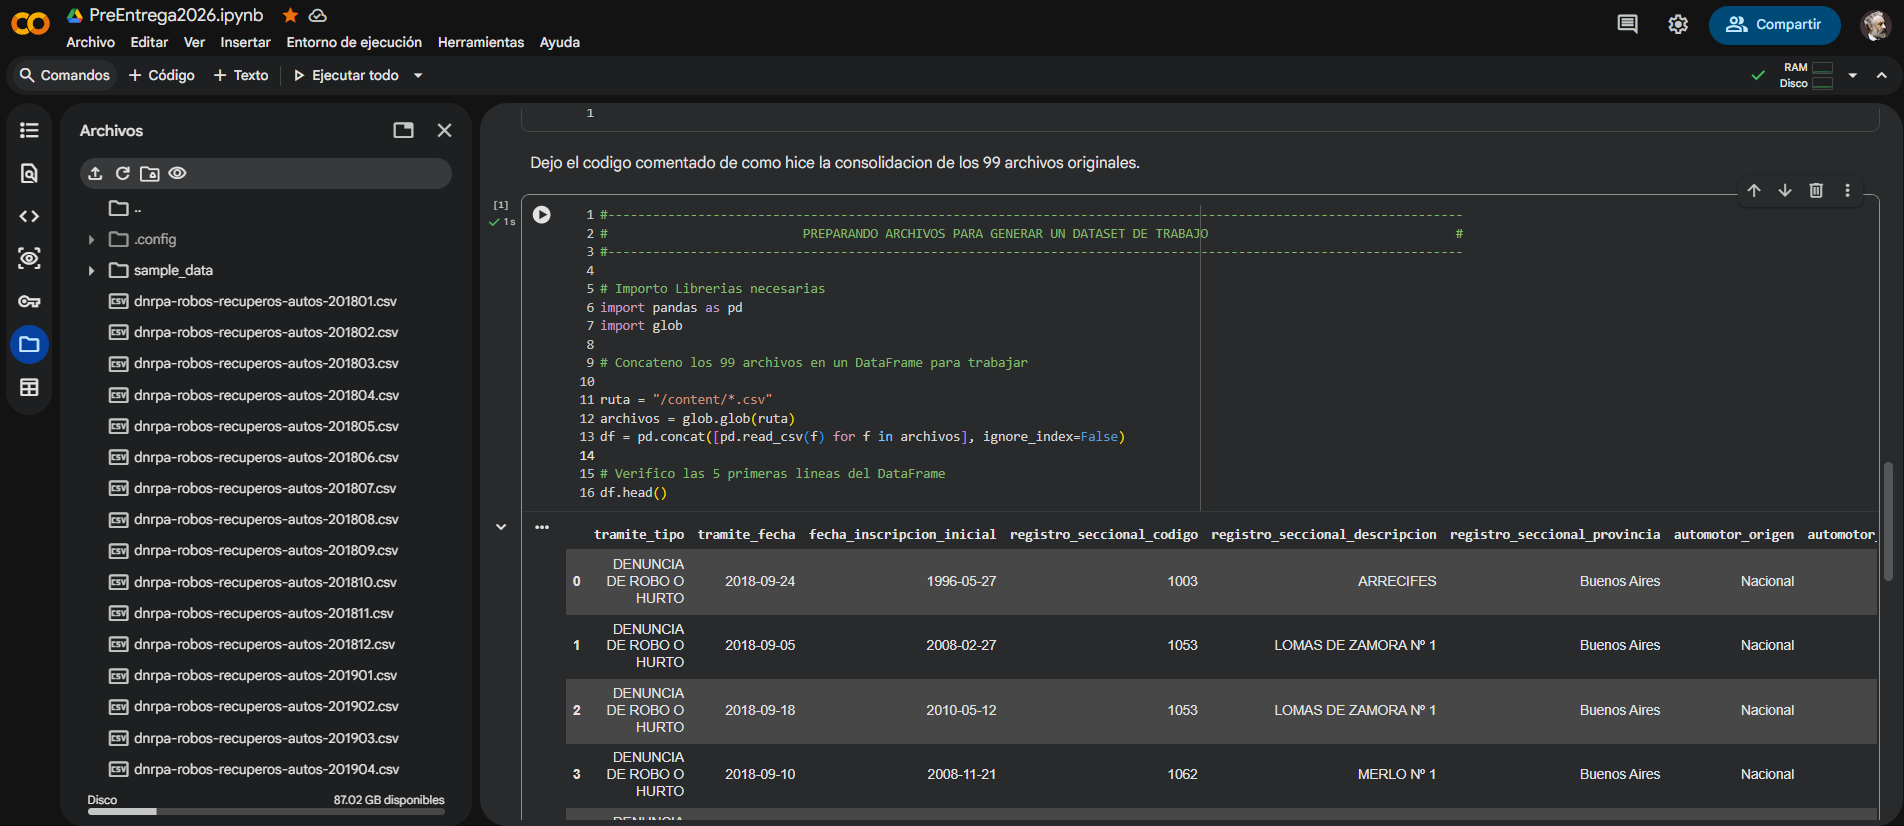

(Print #04)

## *Creo el Archivo ya consolidado y lo descargo en mi PC* 👇

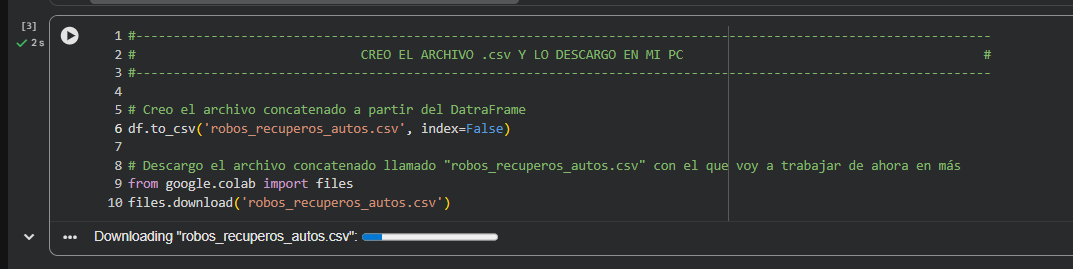

## ⛓️‍💥 *Dejo comentado el Código utilizado con el que consolidé los 99 archivos* 👇

In [ ]:
#------------------------------------------------------------------------------------------------------------------
#                          PREPARANDO ARCHIVOS PARA GENERAR UN DATASET DE TRABAJO                                 #
#------------------------------------------------------------------------------------------------------------------

# Importo Librerias necesarias
#import pandas as pd
#import glob

# Concateno los 99 archivos en un DataFrame para trabajar

#ruta = "/content/*.csv"
#archivos = glob.glob(ruta)
#df = pd.concat([pd.read_csv(f) for f in archivos], ignore_index=False)

# Verifico las 5 primeras lineas del DataFrame
#df.head()

In [ ]:
#------------------------------------------------------------------------------------------------------------------
#                              CREO EL ARCHIVO .csv Y LO DESCARGO EN MI PC                                        #
#------------------------------------------------------------------------------------------------------------------

# Creo el archivo concatenado a partir del DatraFrame
#df.to_csv('robos_recuperos_autos.csv', index=False)

# Descargo el archivo concatenado llamado "robos_recuperos_autos.csv" con el que voy a trabajar de ahora en más
#from google.colab import files
#files.download('robos_recuperos_autos.csv')

In [ ]:
#------------------------------------------------------------------------------------------------------------------
#                                    BORRO LOS 99 ARCHIVOS ANTES CARGADOS                                         #
#------------------------------------------------------------------------------------------------------------------

#!rm *.csv


# 🚀 *Acá comienza el análisis del Dataset elegido, con el archivo ya consolidado* 👇

⚙️ PREPARACION DEL ENTORNO

#📟⚡ **RAPIDA EXPLORACION DEL DATASET** - CONSOLIDADO 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
#                                         P R I M E R     V I S T A Z O     A L     D A T A S E T
# ------------------------------------------------------------------------------------------------------------------------------------------------


# ------------------------------------------------------------------------------------------------------------------------------------------------
# IMPORTO LAS LIBRERIAS NECESARIAS:
# ------------------------------------------------------------------------------------------------------------------------------------------------

import pandas as pd                 # Para todo lo general
import numpy as np                  # Para trabajar con datos
import matplotlib.pyplot as plt     # Para creación de Gráficos
from scipy import stats as st       # Para pruebas Estadísticas
import math as mt                   # Para funciones Matemáticas
import kagglehub                    # Para importar directamente desde Kaggle.com
import os                           # Para acceso a comandos del Sistema Operativo
import unicodedata                  # Para normalizar texto y formatos
import datetime                     # Para trabajar con fechas
import seaborn as sns               # Para creación de Gráficos


from sklearn.model_selection import train_test_split # Para separar datos para entrenar el modelo y luego evaluarlo con datos no vistos
from sklearn.linear_model import LogisticRegression  # Para predecir categorías binarias (Sí/No, 0/1, fraude/no fraude, aprobado/no aprobado)
from sklearn.metrics import classification_report    # Para ver precisión, recall, f1-score y support por clase
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,                 # Para medir exactitud general del modelo
    classification_report,          # Para ver precisión, recall, f1-score y support por clase
    confusion_matrix,               # Para ver falsos positivos, falsos negativos, verdaderos positivos y negativos
    ConfusionMatrixDisplay          # Para Mostrar errores del modelo de forma clara y profesional
    )

!pip install category_encoders
from category_encoders import TargetEncoder     #Para variables con muchas categorías (Alta cardinalidad)
from sklearn.preprocessing import LabelEncoder  #Para la variable objetivo (Y)

from sklearn.ensemble import RandomForestClassifier                 # Para importar Algoritmo de RandomForest
from sklearn.metrics import classification_report, confusion_matrix # Para generar la Matriz de Confusión


# ------------------------------------------------------------------------------------------------------------------------------------------------
# CARGO EL DATASET:
# ------------------------------------------------------------------------------------------------------------------------------------------------

df = pd.read_csv("robos_recuperos_autos.csv")

# EXPLORACION RAPIDA DEL ARCHIVO: Muestro shape

print("─"*180)
print("EXPLORACION RAPIDA DEL DATASET:")
print()
print("SHAPE:", df.shape)
print("─"*180)


# ------------------------------------------------------------------------------------------------------------------------------------------------
# ⚠️ WARNING DE COLAB EN ALGUNAS COLUMNAS DEL DATASET IMPORTADO 👇 MUESTRAN TIPOS DE DATOS MEZCLADOS:
# ------------------------------------------------------------------------------------------------------------------------------------------------

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.1 MB/s eta 0:00:00
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
EXPLORACION RAPIDA DEL DATASET:

SHAPE: (312628, 27)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/tmp/ipykernel_1689/607854759.py:46: DtypeWarning: Columns (8,20,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("robos_recuperos_autos.csv")


**NOTA:** Con el Shape anterior 👆 (en la vista rápida del dataset), se observa que hay **27** columnas y no **25** como se esperaba. Comienzo entonces con una exploración más detallada (EDA) 👇 a fín de entender que son esas 2 columas de más.

#🔎 **ANALISIS EXPLORATORIO DE DATOS** (EDA) CONOCER MEJOR LOS DATOS 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
#                                        V I S T A    G E N E R A L    D E L    D A T A S E T
# ------------------------------------------------------------------------------------------------------------------------------------------------

# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 1: CANTIDAD DE FILAS Y COLUMNAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CARGO EL DATASET
df=pd.read_csv("robos_recuperos_autos.csv",low_memory=False) # para sacar el Warning de Colab

# MUESTRO CANTIDAD DE FILAS Y COLUMNAS QUE TIENE EL DATASET:
print("─"*180)
print("CANTIDAD DE FILAS Y COLUMNAS:", df.shape)
print("─"*180)

# MUESTRO EL NOMBRE DE CADA COLUMNA:
print("─"*180)
print("NOMBRES DE LAS COLUMNAS:")
print("─"*180)
display(df.columns.tolist())
print("─"*180)
print()

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE FILAS Y COLUMNAS: (312628, 27)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
NOMBRES DE LAS COLUMNAS:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


['tramite_tipo',
 'tramite_fecha',
 'fecha_inscripcion_inicial',
 'registro_seccional_codigo',
 'registro_seccional_descripcion',
 'registro_seccional_provincia',
 'automotor_origen',
 'automotor_anio_modelo',
 'automotor_tipo_codigo',
 'automotor_tipo_descripcion',
 'automotor_marca_codigo',
 'automotor_marca_descripcion',
 'automotor_modelo_codigo',
 'automotor_modelo_descripcion',
 'automotor_uso_codigo',
 'automotor_uso_descripcion',
 'titular_tipo_persona',
 'titular_domicilio_localidad',
 'titular_domicilio_provincia',
 'titular_genero',
 'titular_anio_nacimiento',
 'titular_pais_nacimiento',
 'titular_porcentaje_titularidad',
 'titular_domicilio_provincia_indec_id',
 'titular_pais_nacimiento_indec_id',
 'titular_domicilio_provincia_id',
 'titular_pais_nacimiento_id']

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────



In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 2: INFORMACION GENERAL
# ------------------------------------------------------------------------------------------------------------------------------------------------

# MUESTRO LA INFORMACION GENERAL DEL DATASET PARA VER TIPO DE DATOS EN COLUMNAS:
print("─"*180)
print("INFORMACION GENERAL DEL DATASET:")
print("─"*180)
display(df.info())

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
INFORMACION GENERAL DEL DATASET:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312628 entries, 0 to 312627
Data columns (total 27 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   tramite_tipo                          312628 non-null  object 
 1   tramite_fecha                         312628 non-null  object 
 2   fecha_inscripcion_inicial             312624 non-null  object 
 3   registro_seccional_codigo             312628 non-null  int64  
 4   registro_seccional_descripcion        312620 non-null  object 
 5   registro_secc

None

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 3: INFORMACION TIPO DE COLUMNAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# COLUMNAS NUMERICAS
print("─"*180)
print ("COLUMNAS NUMERICAS: ")
print("─"*180)
display (df.select_dtypes(include="number").columns)
print("─"*180)
print()
print()

# COLUMNAS NO NUMERICAS O CATEGORICAS
print("─"*180)
print ("COLUMNAS NO NUMERICAS O CATEGORICAS: ")
print("─"*180)
display (df.select_dtypes(exclude="number").columns)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS NUMERICAS: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Index(['registro_seccional_codigo', 'automotor_anio_modelo',
       'automotor_uso_codigo', 'titular_porcentaje_titularidad',
       'titular_domicilio_provincia_indec_id',
       'titular_domicilio_provincia_id'],
      dtype='object')

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS NO NUMERICAS O CATEGORICAS: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Index(['tramite_tipo', 'tramite_fecha', 'fecha_inscripcion_inicial',
       'registro_seccional_descripcion', 'registro_seccional_provincia',
       'automotor_origen', 'automotor_tipo_codigo',
       'automotor_tipo_descripcion', 'automotor_marca_codigo',
       'automotor_marca_descripcion', 'automotor_modelo_codigo',
       'automotor_modelo_descripcion', 'automotor_uso_descripcion',
       'titular_tipo_persona', 'titular_domicilio_localidad',
       'titular_domicilio_provincia', 'titular_genero',
       'titular_anio_nacimiento', 'titular_pais_nacimiento',
       'titular_pais_nacimiento_indec_id', 'titular_pais_nacimiento_id'],
      dtype='object')

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 4: TIPOS DE VARIABLES HALLADAS EN EL DATASET Y CANTIDAD DE VALORES UNICOS POR COLUMNAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# SEPARO LAS COLUMNAS SEGUN EL TIPO DE DATO
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

# VERIFICO CUANTOS VALORES UNICOS HAY EN CADA COLUMNA CATEGORICA
print("─"*180)
print("CANTIDAD DE VALORES UNICOS POR CADA VARIABLE CATEGORICA: ")
print("─"*180)
for columna in columnas_categoricas:
   display(f"{columna}: {df[columna].nunique()} valores únicos")
   display(df[columna].value_counts())
   display("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE VALORES UNICOS POR CADA VARIABLE CATEGORICA: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


'tramite_tipo: 3 valores únicos'

,count
tramite_tipo,
DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA,239603
DENUNCIA DE ROBO O HURTO,61668
COMUNICACIÓN DE RECUPERO,11357


'────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────'

'tramite_fecha: 2048 valores únicos'

...

,count
titular_pais_nacimiento_indec_id,
ARG,40623
PRY,856
BOL,361
URY,210
PER,180
ITA,155
CHL,79
ESP,64
COL,24


'────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────'

'titular_pais_nacimiento_id: 92 valores únicos'

,count
titular_pais_nacimiento_id,
ARG,150929
200.0,88099
PRY,3785
221.0,2361
BOL,1426
...,...
220.0,1
GBR,1
413.0,1


'────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────'

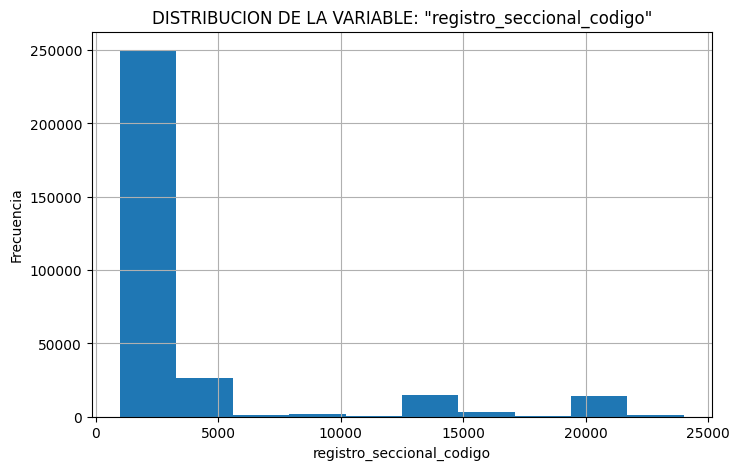

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 5: EXPLORO UNA DE LAS VARIABLES NUMERICAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# HISTOGRAMA SOBRE LA VARIABLE "registro_seccional_codigo" PARA VER SU FRECUENCIA
plt.figure(figsize=(8,5))
df["registro_seccional_codigo"].hist(bins=10) # AGRUPADO EN 10
plt.title('DISTRIBUCION DE LA VARIABLE: "registro_seccional_codigo"')
plt.xlabel("registro_seccional_codigo")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 6: EXPLORO UNA DE LAS VARIABLES CATEGORICAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("─"*180)
print ('LOS 10 VALORES MAS FRECUENTES DE LA COLUMNA : "registro_seccional_descripcion"')
print("─"*180)
display(df["registro_seccional_descripcion"].value_counts().head(10))

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LOS 10 VALORES MAS FRECUENTES DE LA COLUMNA : "registro_seccional_descripcion"
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,count
registro_seccional_descripcion,
LA MATANZA Nº 09,4823
LA MATANZA Nº 10,4094
LOMAS DE ZAMORA Nº 7,3083
LA MATANZA Nº 03,2922
LA MATANZA Nº 04,2905
LA MATANZA Nº 05,2872
MALVINAS ARGENTINAS Nº 3,2780
LA MATANZA Nº 13,2517
ESTEBAN ECHEVERRIA Nº 3,2443


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 7: DIMENSIONES DEL DATASET PARTE 3: RESUMEN ESTADISTICO
# ------------------------------------------------------------------------------------------------------------------------------------------------

# MUESTRO RESUMEN ESTADISTICO:
print("─"*180)
print("RESUMEN ESTADISTICO:")
print("─"*180)
display(df.describe())

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RESUMEN ESTADISTICO:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,registro_seccional_codigo,automotor_anio_modelo,automotor_uso_codigo,titular_porcentaje_titularidad,titular_domicilio_provincia_indec_id,titular_domicilio_provincia_id
count,312628.000000,311815.000000,312619.000000,312628.000000,46034.000000,266593.000000
mean,3314.016611,2006.703331,1.015162,97.703685,11.374549,13.040575
std,5036.145593,34.526722,0.304889,10.539575,17.786546,19.775955
min,1001.000000,20.000000,0.000000,1.000000,2.000000,2.000000
25%,1160.000000,2001.000000,1.000000,100.000000,6.000000,6.000000
50%,1252.000000,2008.000000,1.000000,100.000000,6.000000,6.000000
75%,2062.000000,2013.000000,1.000000,100.000000,6.000000,6.000000
max,24008.000000,2026.000000,9.000000,100.000000,94.000000,94.000000


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 8: PRIMERAS Y ULTIMAS 5 FILAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# MUESTRO PRIMERAS 5 FILAS DEL ARCHIVO:
print("─"*180)
print("PRIMERAS 5 FILAS:")
print("─"*180)
display(df.head())

#MUESTRO ULTIMAS 5 FILAS DEL ARCHIVO:
print("─"*180)
print("ULTIMAS 5 FILAS:")
print("─"*180)
display(df.tail())

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PRIMERAS 5 FILAS:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,tramite_tipo,tramite_fecha,fecha_inscripcion_inicial,registro_seccional_codigo,registro_seccional_descripcion,registro_seccional_provincia,automotor_origen,automotor_anio_modelo,automotor_tipo_codigo,automotor_tipo_descripcion,...,titular_domicilio_localidad,titular_domicilio_provincia,titular_genero,titular_anio_nacimiento,titular_pais_nacimiento,titular_porcentaje_titularidad,titular_domicilio_provincia_indec_id,titular_pais_nacimiento_indec_id,titular_domicilio_provincia_id,titular_pais_nacimiento_id
0,DENUNCIA DE ROBO O HURTO,2018-09-24,1996-05-27,1003,ARRECIFES,Buenos Aires,Nacional,1996.0,NaN,BERLINA 5 PTAS,...,ARRECFES,BUENOS AIRES,Masculino,1980,Argentina,100.0,6.0,ARG,NaN,NaN
1,DENUNCIA DE ROBO O HURTO,2018-09-05,2008-02-27,1053,LOMAS DE ZAMORA Nº 1,Buenos Aires,Nacional,2008.0,NaN,SEMIRREMOLQUE PORTAC,...,LOMAS DE ZAMORA,BUENOS AIRES,No identificado,1965,Argentina,100.0,6.0,ARG,NaN,NaN
2,DENUNCIA DE ROBO O HURTO,2018-09-18,2010-05-12,1053,LOMAS DE ZAMORA Nº 1,Buenos Aires,Nacional,2010.0,NaN,FURGON 800,...,BANFIELD,BUENOS AIRES,No identificado,1957,Argentina,100.0,6.0,ARG,NaN,NaN
3,DENUNCIA DE ROBO O HURTO,2018-09-10,2008-11-21,1062,MERLO Nº 1,Buenos Aires,Nacional,2008.0,NaN,FURGON COURT TYPE 600,...,MERLO,BUENOS AIRES,Femenino,1984,Argentina,100.0,6.0,ARG,NaN,NaN
4,DENUNCIA DE ROBO O HURTO,2018-09-10,2001-06-15,1062,MERLO Nº 1,Buenos Aires,Nacional,2001.0,NaN,SEDAN,...,MERLO,BUENOS AIRES,Femenino,1991,Argentina,100.0,6.0,ARG,NaN,NaN


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ULTIMAS 5 FILAS:
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,tramite_tipo,tramite_fecha,fecha_inscripcion_inicial,registro_seccional_codigo,registro_seccional_descripcion,registro_seccional_provincia,automotor_origen,automotor_anio_modelo,automotor_tipo_codigo,automotor_tipo_descripcion,...,titular_domicilio_localidad,titular_domicilio_provincia,titular_genero,titular_anio_nacimiento,titular_pais_nacimiento,titular_porcentaje_titularidad,titular_domicilio_provincia_indec_id,titular_pais_nacimiento_indec_id,titular_domicilio_provincia_id,titular_pais_nacimiento_id
312623,DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA,2019-12-27,2011-09-27,1186,MORENO Nº 2,Buenos Aires,Nacional,2011.0,12.0,SEDAN 4 PTAS,...,MORENO,BUENOS AIRES,Femenino,1975,ARGENTINA,100.0,NaN,NaN,6.0,ARG
312624,DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA,2019-12-30,2015-09-25,1186,MORENO Nº 2,Buenos Aires,Nacional,2015.0,17.0,SEDAN 5 PUERTAS,...,MORENO,BUENOS AIRES,Femenino,1988,ARGENTINA,100.0,NaN,NaN,6.0,ARG
312625,COMUNICACIÓN DE RECUPERO,2019-12-30,2013-04-17,1188,LA PLATA Nº 07,Buenos Aires,Importado,2013.0,4.0,RURAL 5 PTAS,...,LA PLATA,BUENOS AIRES,No aplica,1946,No aplica,100.0,NaN,NaN,6.0,NaN
312626,DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA,2019-12-23,2014-11-04,1318,BERAZATEGUI Nº 5,Buenos Aires,Protocolo 21,2014.0,5.0,SEDAN 5 PUERTAS,...,BERAZATEGUI,BUENOS AIRES,Masculino,1964,ARGENTINA,100.0,NaN,NaN,6.0,ARG
312627,DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA,2019-12-30,2010-08-23,7007,TRELEW Nº 1,Chubut,Protocolo 21,2010.0,2.0,SEDAN 4 PTAS,...,TRELEW,CHUBUT,Masculino,1974,CHILE,100.0,NaN,NaN,26.0,CHL


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 9: FILAS DUPLICADAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CUENTO EL TOTAL DE LAS FILAS DUPLICADAS EN TODO EL DATASET (39 filas duplicadas fueron halladas)
duplicados = df.duplicated().sum()

print("─"*180)
print("FILAS DUPLICADOS: ", duplicados)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
FILAS DUPLICADOS:  39
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 10: VALORES NULOS Y NAN
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CUENTO EL TOTAL DE LOS VALORES NULOS EN TODO EL DATASET
totalnulos = df.isnull().sum().sum()

print("─"*180)
print("VALORES NULOS: ", totalnulos)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALORES NULOS:  663580
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


**NOTA:** Se presume que tanta cantidad de nulos 👆 responde a que hay 2 columnas de mas que no deberian exitir como se había visto en el Shape anterior.

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PARTE 11: VERIFICO CANTIDAD DE VALORES NULOS POR CADA COLUMNA
# ------------------------------------------------------------------------------------------------------------------------------------------------

# TABLA DE VALORES NULOS
print("─"*180)
print("TABLA CON VALORES NULOS POR CADA COLUMNA")
print("─"*180)

# CALCULO LA CANTIDAD DE VALORES NULOS POR CADA COLUMNA Y EL % QUE REPRESENTA SOBRE EL TOTAL DEL DATASET
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum()/len(df)*100).round(2)

# CREO UNA TABLA PARA MOSTRAR LOS NULOS POR CADA COLUMNA
tabla_nulos = pd.DataFrame({
    "Nulos": nulos,
    "% Nulos": porcentaje_nulos
}).sort_values("% Nulos", ascending=False)

display(tabla_nulos)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TABLA CON VALORES NULOS POR CADA COLUMNA
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,Nulos,% Nulos
titular_pais_nacimiento_indec_id,269941,86.35
titular_domicilio_provincia_indec_id,266594,85.28
titular_pais_nacimiento_id,61371,19.63
titular_domicilio_provincia_id,46035,14.73
automotor_tipo_codigo,9746,3.12
automotor_modelo_codigo,4775,1.53
automotor_marca_codigo,3952,1.26
automotor_anio_modelo,813,0.26
titular_domicilio_localidad,260,0.08
titular_anio_nacimiento,54,0.02


# 💡 *Conclusión sobre la Exploración de datos EDA:* 👆

El Dataset se encuentra "muy sucio" es decir tiene valores faltantes, inconsistencias varias que generan duplicidad de datos y columnas que sobran.

Presumo que la imputación de los datos no sigue un parametro bien definido o bien los imputs corresponden a sistemas distintos (cada seccional posee distintos sistemas) lo que hacen que un mismo dato tenga multiples variantes en su descripción/tipificación.

#🧹🧹 **LIMPIEZA DE DATOS** (DATA CLEANING) 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# SE DETECTA UN LIGERO CAMBIO DE NOMBRES EN LAS ULTIMAS 4 COLUMNAS QUE GENERA DUPLICIDAD DE DATOS Y GRAN CANTIDAD DE VALORES NULOS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# REVISO QUE TIENEN LAS COLUMNAS 23 A LA 26 (ULTIMAS 4)
print("─"*180)
print("CONTENIDO DE LAS 4 ULTIMAS COLUMNAS")
print("─"*180)
display(df.iloc[:, [23, 24, 25, 26]])

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CONTENIDO DE LAS 4 ULTIMAS COLUMNAS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,titular_domicilio_provincia_indec_id,titular_pais_nacimiento_indec_id,titular_domicilio_provincia_id,titular_pais_nacimiento_id
0,6.0,ARG,NaN,NaN
1,6.0,ARG,NaN,NaN
2,6.0,ARG,NaN,NaN
3,6.0,ARG,NaN,NaN
4,6.0,ARG,NaN,NaN
...,...,...,...,...
312623,NaN,NaN,6.0,ARG
312624,NaN,NaN,6.0,ARG
312625,NaN,NaN,6.0,NaN
312626,NaN,NaN,6.0,ARG


**NOTA:** A partir de ahora el dataframe pasa de llamarse df a llamarse ***dfcorregido*** 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CORRIJO EL PROBLEMA DE LAS CUATRO ULTIMAS COLUMNAS Y RENOMBRO EL DATAFRAME AHORA LO LLAMO: "dfcorregido"
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UNA COPIA FISICA DEL DATASET ORIGINAL AL QUE VOY A LLAMAR: "dfcorregido"
dfcorregido = df.copy()

# PASO LOS VALORES DE LAS COLUMNAS QUE CONTIENEN EN EL TITULO "indec" A LAS PRINCIPALES SOLO EN LAS FILAS VACIAS
# USO "fillna" PARA RELLENAR LOS HUECOS DE LAS COLUMNAS DESTINO CON LOS DATOS DE LA DE ORIGEN

dfcorregido["titular_domicilio_provincia_id"] = df["titular_domicilio_provincia_id"].fillna(df["titular_domicilio_provincia_indec_id"])
dfcorregido["titular_pais_nacimiento_id"] = df["titular_pais_nacimiento_id"].fillna(df["titular_pais_nacimiento_indec_id"])

# BORRO LAS COLUMNAS INCORRECTAS QUE CONTIENEN EN SU TITULO "indec"
columnas_a_borrar = ["titular_domicilio_provincia_indec_id", "titular_pais_nacimiento_indec_id"]

# USO errors="ignore" POR SEGURIDAD POR SI ALGUNA COLUMNA YA NO EXISTE
dfcorregido.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

# VERIFICO QUE VUELVO A TENER SOLO 25 COLUMNAS
print("─"*180)
print(f"TOTAL DE COLUMNAS FINALES: {len(dfcorregido.columns)}")
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TOTAL DE COLUMNAS FINALES: 25
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# ✂️ *Eliminación de Columnas innecesarias* 👇

**NOTA:** En esta instancia decidí borrar 10 columnas (que se mencionan mas abajo) debido a que no son necesarias para el entrenamiento de mi modelo, dado que no son variables predictoras.
<br>
<br>
***Columnas a Eliminar:***
* automotor_tipo_codigo
* automotor_marca_codigo
* automotor_modelo_codigo
* automotor_uso_codigo
* automotor_uso_descripcion
* titular_tipo_persona
* titular_pais_nacimiento
* titular_porcentaje_titularidad
* titular_domicilio_provincia_id
* titular_pais_nacimiento_id
* titular_domicilio_localidad


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ELIMINO LAS COLUMNAS QUE CONSIDERO NO NECESITO PARA MI PROCESO DE MACHINE LEARNING
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UNA LISTA DE LAS COLUMNAS QUE VOY A BORRAR
elimino_columnas = [
    "automotor_tipo_codigo", "automotor_marca_codigo", "automotor_modelo_codigo",
    "automotor_uso_codigo", "automotor_uso_descripcion", "titular_tipo_persona",
    "titular_pais_nacimiento", "titular_porcentaje_titularidad",
    "titular_domicilio_provincia_id", "titular_pais_nacimiento_id","titular_domicilio_localidad"
]
# BORRO LAS COLUMNAS
dfcorregido = dfcorregido.drop(columns=elimino_columnas, errors='ignore') # errors='ignore' evita que el código falle si se vuelve a correr y la celda y las columnas ya no existen

print("─"*180)
print("SE ELIMINARON LAS COLUMNAS: ", elimino_columnas)
print("─"*180)
print()

print("─"*180)
print("COLUMNAS RESTANTES: ", dfcorregido.columns.tolist())
print("─"*180)
print()
# VERIFICO LA NUEVA CANTIDAD DE COLUMNAS
print("─"*180)
print(f"TOTAL DE COLUMNAS FINALES: {len(dfcorregido.columns)}")
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
SE ELIMINARON LAS COLUMNAS:  ['automotor_tipo_codigo', 'automotor_marca_codigo', 'automotor_modelo_codigo', 'automotor_uso_codigo', 'automotor_uso_descripcion', 'titular_tipo_persona', 'titular_pais_nacimiento', 'titular_porcentaje_titularidad', 'titular_domicilio_provincia_id', 'titular_pais_nacimiento_id', 'titular_domicilio_localidad']
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS RESTANTES:  ['tramite_tipo', 'tramite_fecha', 'fecha_inscripcion_inicial', 'registro_seccional_codigo', 'r

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# RECUENTO EL TOTAL DE LAS FILAS DUPLICADAS EN TODO EL DATASET LAS BORRO (42 filas duplicadas fueron halladas)
# ------------------------------------------------------------------------------------------------------------------------------------------------

# RECUENTO EL TOTAL DE LAS FILAS DUPLICADAS
duplicados = dfcorregido.duplicated().sum()

print("─"*180)
print("CANTIDAD DE FILAS DUPLICADAS: ", duplicados)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE FILAS DUPLICADAS:  42
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ELIMINO LAS FILAS DUPLICADAS - SE HABIAN ENCONTRADO 42 FILAS DUPLICADAS -
# ------------------------------------------------------------------------------------------------------------------------------------------------

# ELIMINO LAS FILAS DUPLICADAS
dfcorregido = dfcorregido.drop_duplicates()
duplicados = dfcorregido.duplicated().sum()
print("─"*180)
print("CANTIDAD DE FILAS DUPLICADAS: ", duplicados)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE FILAS DUPLICADAS:  0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# RECUENTO EL TOTAL DE LOS VALORES NULOS EN TODO EL DATASET
# ------------------------------------------------------------------------------------------------------------------------------------------------

totalnulos = dfcorregido.isnull().sum().sum()

print("─"*180)
print("VALORES NULOS: ", totalnulos)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALORES NULOS:  887
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CONVIERTO LAS COLUMNAS CON FECHAS EN FORMATO DATETIME
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO LAS DOS COLUMNAS CON FECHAS
dfcorregido['tramite_fecha'] = pd.to_datetime(dfcorregido['tramite_fecha'])
dfcorregido['fecha_inscripcion_inicial'] = pd.to_datetime(dfcorregido['fecha_inscripcion_inicial'])

print("─"*180)
print("PROCESO DE CONVERSION REALIZADO: PASARON DE TEXTO A FORMATO FECHAS (año-mes-día)")
print("─"*180)
print()

# OBSERVO LOS RANGOS MAX Y MIN
print("─"*180)
print(f"COLUMNA TRAMITE FECHA, VALOR MINIMO: {dfcorregido['tramite_fecha'].min()} - VALOR MAXIMO: {dfcorregido['tramite_fecha'].max()}")
print("─"*180)
print()
print("─"*180)
print(f"COLUMNA FECHA INSCRIPCION, VALOR MINIMO: {dfcorregido['fecha_inscripcion_inicial'].min()} - VALOR MAXIMO: {dfcorregido['fecha_inscripcion_inicial'].max()}")
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PROCESO DE CONVERSION REALIZADO: PASARON DE TEXTO A FORMATO FECHAS (año-mes-día)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNA TRAMITE FECHA, VALOR MINIMO: 2018-01-02 00:00:00 - VALOR MAXIMO: 2026-03-31 00:00:00
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CONVIERTO EN NUMEROS LA COLUMNA 'titular_anio_nacimiento'
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO EN NUMERO Y PASO A NaN TODO LO QUE NO SEA NUMERO
dfcorregido['titular_anio_nacimiento'] = pd.to_numeric(dfcorregido['titular_anio_nacimiento'], errors='coerce') #'errors=coerce' transforma cualquier cosa que no sea un número en un valor nulo (NaN)

# VERIFICO CUANTOS NULOS TIENE LA COLUMNA (NULOS O NaN)
nulos_seccional = dfcorregido['titular_anio_nacimiento'].isnull().sum()
print("─"*180)
print(f"LA COLUMNA titular_anio_nacimiento TIENE {nulos_seccional} VALORES NULOS")
print("─"*180)
print()

# CALCULO LA MEDIANA PARA COMPLETAR CON ESO LOS NaN
mediana_anio = dfcorregido['titular_anio_nacimiento'].median()
dfcorregido['titular_anio_nacimiento'] = dfcorregido['titular_anio_nacimiento'].fillna(mediana_anio)

# PASO LOS VALORES A NUMEROS ENTEROS
dfcorregido['titular_anio_nacimiento'] = dfcorregido['titular_anio_nacimiento'].astype(int)

print("─"*180)
print(f"LOS VALORES NaN FUERON COMPLETADOS CON LA MEDIANA, ES DECIR CON EL AÑO: {mediana_anio}")
print("─"*180)
print()
print("─"*180)
print("TIPO DE DATO DE LA COLUMNA titular_anio_nacimiento:", dfcorregido['titular_anio_nacimiento'].dtype)
#print(dfcorregido['titular_anio_nacimiento'].dtype)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LA COLUMNA titular_anio_nacimiento TIENE 73 VALORES NULOS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LOS VALORES NaN FUERON COMPLETADOS CON LA MEDIANA, ES DECIR CON EL AÑO: 1979.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

👆 **NOTA:** Los valores pasados a NaN luego fueron completados con la Mediana del campo: "titular_anio_nacimiento" es decir 1979

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CONVIERTO EN NUMEROS LA COLUMNA 'automotor_anio_modelo'
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO EN NUMERO Y PASO A NaN TODO LO QUE NO SEA NUMERO
dfcorregido['automotor_anio_modelo'] = pd.to_numeric(dfcorregido['automotor_anio_modelo'], errors='coerce') #'errors=coerce' transforma cualquier cosa que no sea un número en un valor nulo (NaN)

# VERIFICO CUANTOS NULOS TIENE LA COLUMNA (NULOS O NaN)
nulos_seccional = dfcorregido['automotor_anio_modelo'].isnull().sum()
print("─"*180)
print(f"LA COLUMNA automotor_anio_modelo TIENE {nulos_seccional} VALORES NULOS")
print("─"*180)
print()

# CALCULO LA MEDIANA PARA COMPLETAR CON ESO LOS NaN
mediana_anio1 = dfcorregido['automotor_anio_modelo'].median()
dfcorregido['automotor_anio_modelo'] = dfcorregido['automotor_anio_modelo'].fillna(mediana_anio1)

# PASO LOS VALORES A NUMEROS ENTEROS
dfcorregido['automotor_anio_modelo'] = dfcorregido['automotor_anio_modelo'].astype(int)

print("─"*180)
print(f"LOS VALORES NaN FUERON COMPLETADOS CON LA MEDIANA, ES DECIR CON EL AÑO: {mediana_anio1}")
print("─"*180)
print()
print("─"*180)
print("TIPO DE DATO DE LA COLUMNA automotor_anio_modelo:", dfcorregido['automotor_anio_modelo'].dtype)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LA COLUMNA automotor_anio_modelo TIENE 812 VALORES NULOS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LOS VALORES NaN FUERON COMPLETADOS CON LA MEDIANA, ES DECIR CON EL AÑO: 2008.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

👆 **NOTA:** Los valores pasados a NaN luego fueron completados con la Mediana del campo: "automotor_anio_modelo" es decir 2008

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CONVIERTO EN NUMEROS LA COLUMNA 'registro_seccional_codigo'
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO EN NUMERO Y PASO A NaN TODO LO QUE NO SEA NUMERO
dfcorregido['registro_seccional_codigo'] = pd.to_numeric(dfcorregido['registro_seccional_codigo'], errors='coerce') #'errors=coerce' transforma cualquier cosa que no sea un número en un valor nulo (NaN)

# VERIFICO CUANTOS NULOS TIENE LA COLUMNA (NULOS O NaN)
nulos_seccional = dfcorregido['registro_seccional_codigo'].isnull().sum()
print("─"*180)
print(f"LA COLUMNA registro_seccional_codigo TIENE {nulos_seccional} VALORES NULOS")
print("─"*180)

# PASO LOS VALORES A NUMEROS ENTEROS
dfcorregido['registro_seccional_codigo'] = dfcorregido['registro_seccional_codigo'].astype(int)

print("─"*180)
print("TIPO DE DATO DE LA COLUMNA registro_seccional_codigo:", dfcorregido['registro_seccional_codigo'].dtype)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LA COLUMNA registro_seccional_codigo TIENE 0 VALORES NULOS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TIPO DE DATO DE LA COLUMNA registro_seccional_codigo: int64
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# VUELVO A VER LA INFORMACION POR TIPO DE COLUMNAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# COLUMNAS NUMERICAS
print("─"*180)
print ("COLUMNAS NUMERICAS: ")
print("─"*180)
display (df.select_dtypes(include="number").columns)
print("─"*180)
print()
print()

# COLUMNAS NO NUMERICAS O CATEGORICAS
print("─"*180)
print ("COLUMNAS NO NUMERICAS O CATEGORICAS: ")
print("─"*180)
display (df.select_dtypes(exclude="number").columns)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS NUMERICAS: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Index(['registro_seccional_codigo', 'automotor_anio_modelo',
       'automotor_uso_codigo', 'titular_porcentaje_titularidad',
       'titular_domicilio_provincia_indec_id',
       'titular_domicilio_provincia_id'],
      dtype='object')

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS NO NUMERICAS O CATEGORICAS: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Index(['tramite_tipo', 'tramite_fecha', 'fecha_inscripcion_inicial',
       'registro_seccional_descripcion', 'registro_seccional_provincia',
       'automotor_origen', 'automotor_tipo_codigo',
       'automotor_tipo_descripcion', 'automotor_marca_codigo',
       'automotor_marca_descripcion', 'automotor_modelo_codigo',
       'automotor_modelo_descripcion', 'automotor_uso_descripcion',
       'titular_tipo_persona', 'titular_domicilio_localidad',
       'titular_domicilio_provincia', 'titular_genero',
       'titular_anio_nacimiento', 'titular_pais_nacimiento',
       'titular_pais_nacimiento_indec_id', 'titular_pais_nacimiento_id'],
      dtype='object')

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# 🔠 NORMALIZACION DEL TEXTO 👇

Como se pudo ver en el EDA, hay muchos datos duplicados a partir de inconsistencias en el texto, intento normalizar todo aquello que creo que reduce la cantidad de duplicados en columans que son clave para el análisis futuro.

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PASO A MAYUSCULAS LAS COLUMNAS CATEGORICAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UNA LISTA CON LAS COLUMNAS
columnas_texto = ["automotor_marca_descripcion","automotor_modelo_descripcion","automotor_origen","automotor_tipo_descripcion","registro_seccional_descripcion","registro_seccional_provincia","titular_domicilio_provincia","titular_genero","tramite_tipo"]

# LAS PASO A MAYUSCULAS
for col in columnas_texto:
    dfcorregido[col] = dfcorregido[col].str.upper().str.strip()

# VERIFICO QUE HAYA QUEDADO BIEN
print("─"*180)
print("VERIFICACION DE COLUMNA registro_seccional_provincia: ")
print(dfcorregido["registro_seccional_provincia"].head(3))
print("─"*180)
print()
print("─"*180)
print("VERIFICACION DE COLUMNA titular_genero: ")
print(dfcorregido["titular_genero"].head(3))
print("─"*180)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VERIFICACION DE COLUMNA registro_seccional_provincia: 
0    BUENOS AIRES
1    BUENOS AIRES
2    BUENOS AIRES
Name: registro_seccional_provincia, dtype: object
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VERIFICACION DE COLUMNA titular_genero: 
0          MASCULINO
1    NO IDENTIFICADO
2    NO IDENTIFICADO
Name: titular_genero, dtype: object
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ELIMINO LOS ACENTOS EN TODAS LAS COLUMNAS CATEGORICAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UNA FUNCION
def quitar_acentos(texto):
    if isinstance(texto, str):
        return ''.join(
            c for c in unicodedata.normalize('NFKD', texto)
            if not unicodedata.combining(c)
        )
    return texto

# HAGO UNA LISTA DE LAS COLUMNAS A ELIMINAR ACENTOS
columnas = ["tramite_tipo","tramite_fecha","fecha_inscripcion_inicial","registro_seccional_codigo",
            "registro_seccional_descripcion","registro_seccional_provincia","automotor_origen",
            "automotor_anio_modelo","automotor_tipo_descripcion","automotor_marca_descripcion",
            "automotor_modelo_descripcion","titular_domicilio_provincia","titular_genero"]

# APLICO LA CORRECCION
dfcorregido[columnas] = dfcorregido[columnas].apply(
    lambda col: col.map(quitar_acentos)
)
# COMPRUEBO SI HAY LETRAS CON ACENTOS EN LAS COLUMNAS CORREGIDAS
print("─"*180)
print ("CANTIDAD DE PALABRAS CON ACENTO POR CADA COLUMNA: ")
print("─"*180)
dfcorregido[["tramite_tipo","tramite_fecha","fecha_inscripcion_inicial","registro_seccional_codigo",
            "registro_seccional_descripcion","registro_seccional_provincia","automotor_origen",
            "automotor_anio_modelo","automotor_tipo_descripcion","automotor_marca_descripcion",
            "automotor_modelo_descripcion","titular_domicilio_provincia","titular_genero"]].apply(
    lambda col: col.astype(str).str.contains('[ÁÉÍÓÚÀÈÌÒÙÄËÏÖÜ]', regex=True).sum()
)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE PALABRAS CON ACENTO POR CADA COLUMNA: 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,0
tramite_tipo,0
tramite_fecha,0
fecha_inscripcion_inicial,0
registro_seccional_codigo,0
registro_seccional_descripcion,0
registro_seccional_provincia,0
automotor_origen,0
automotor_anio_modelo,0
automotor_tipo_descripcion,0
automotor_marca_descripcion,0


# 🛠️ *Normalizo algunas Tipificaciones* 👇

 Existen columnas con pequeñas variantes o inconsistencias en sus datos o descipciones que generan duplicidad en el Dataset, intento normalizarlos a fin de corregir y disminuir sus cantidades.

1. Normalización de tipificaciones para evitar duplicados
2. Corrección en la columna tramite_tipo

    •	Reemplazo: "DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA" por "DENUNCIA DE
ROBO O HURTO".

3. Normalización de registro_seccional_provincia

    •	Cambio: "CIUDAD AUTONOMA DE BS.AS." por "CIUDAD AUTONOMA DE BUENOS AIRES".

4. Imputación de nulos en titular_domicilio_provincia

    •	Cuento nulos y los reemplazo por "TUCUMAN".

5. Normalización de provincias en titular_domicilio_provincia

    •	Unifico variantes como:
   
    »	"C.AUTONOMA DE BS.AS" → "CIUDAD AUTONOMA DE BUENOS AIRES"
   
    »	"SGO.DEL ESTERO" → "SANTIAGO DEL ESTERO"
   
    »	"T.DEL FUEGO" → "TIERRA DEL FUEGO"

6. Imputación de nulos en registro_seccional_descripcion
   
    •	Reemplazo valores nulos por "AVELLANEDA No 7".

7. Imputación de nulos en registro_seccional_provincia

    •	Reemplazo nulos por "BUENOS AIRES".

8. Normalización de valores en titular_genero
    
    •	Unifico:
    
    »	"NO IDENTIFICADO" → "NO BINARIO"
    
    »	"NO APLICA" → "NO BINARIO"

9. Imputación de fechas faltantes en fecha_inscripcion_inicial
    
    •	Para filas con fecha nula, asigno una fecha según el año del modelo:
    
    »	Año 2008 → "2008-01-01"
    
    »	Año 1990 → "1990-01-01"
    
    »	Año 1982 → "1982-01-01"
    
    »	Año 2000 → "2000-01-01"

10. Corrección de años inválidos en automotor_anio_modelo

    •	Se detectan años menores a 1885 (fecha de invención del automovil).
    •	Los reemplazo por el año de la columna fecha_inscripcion_inicial.

11. Normalización masiva de registro_seccional_descripcion
    •	Unifico decenas de variantes como:
    
    »	"CATAMARCA N° 4" → "CATAMARCA No 4"

    »	"ITUZAINGO" → "ITUZAINGO No 1"

    »	"MAR DEL PLATA N° 13" → "MAR DEL PLATA No 13"

    »	"YERBA BUENA" → "YERBA BUENA No 1"

    »	etc.


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
#                            NORMALIZO ALGUNAS TIPIFICACIONES CON PEQUEÑAS VARIANTES QUE GENERAN DUPLICIDAD
# ------------------------------------------------------------------------------------------------------------------------------------------------


# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: "tramite_tipo"
# ------------------------------------------------------------------------------------------------------------------------------------------------
dfcorregido["tramite_tipo"] = dfcorregido[
    "tramite_tipo"
].replace("DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA","DENUNCIA DE ROBO O HURTO")

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print("─"*180)
print('( Antes ) COLUMNA: "tramite_tipo" → CANTIDAD DE CASOS TIPIFICADOS COMO  "DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA": ', (dfcorregido["tramite_tipo"] ==  "DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA").sum())
print('(Después) COLUMNA: "tramite_tipo" → CANTIDAD DE CASOS TIPIFICADOS COMO  "DENUNCIA DE ROBO O HURTO": ', (dfcorregido["tramite_tipo"] ==  "DENUNCIA DE ROBO O HURTO").sum() )
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: registro_seccional_provincia
# ------------------------------------------------------------------------------------------------------------------------------------------------
dfcorregido['registro_seccional_provincia'] = dfcorregido[
    'registro_seccional_provincia'
].replace(
    'CIUDAD AUTONOMA DE BS.AS.','CIUDAD AUTONOMA DE BUENOS AIRES')

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print("─"*180)
print('( Antes ) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS TIPIFICADOS COMO "CIUDAD AUTONOMA DE BS.AS.": ', (dfcorregido['registro_seccional_provincia'] == 'CIUDAD AUTONOMA DE BS.AS.').sum())
print('(Después) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS TIPIFICADOS COMO "CIUDAD AUTONOMA DE BUENOS AIRES": ', (dfcorregido['registro_seccional_provincia'] == 'CIUDAD AUTONOMA DE BUENOS AIRES').sum() )
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO CANTIDAD DE CASOS NULOS EN COLUMNA: "titular_domicilio_provincia"
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("─"*180)
print('( Antes ) COLUMNA: "titular_domicilio_provincia" → CANTIDAD DE CASOS NULOS: ',dfcorregido["titular_domicilio_provincia"].isna().sum())

# CAMBIO VALOR NULO DE LA COLUMNA: "titular_domicilio_provincia" POR EL VALOR QUE CORRESPONDE
dfcorregido["titular_domicilio_provincia"] = (dfcorregido["titular_domicilio_provincia"].fillna("TUCUMAN"))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "titular_domicilio_provincia" → CANTIDAD DE CASOS NULOS: ',dfcorregido["titular_domicilio_provincia"].isna().sum())
print("─"*180)
print()

# REVISO TIPIFICACIONES UNICAS EN COLUMNA: "titular_domicilio_provincia"
print('( Antes ) COLUMNA: "titular_domicilio_provincia" → VALORES UNICOS: ', dfcorregido["titular_domicilio_provincia"].unique())
#print('( Antes ) COLUMNA: "titular_domicilio_provincia" → VALORES UNICOS: ' )
#display(sorted(dfcorregido["titular_domicilio_provincia"].dropna().unique()))
print("─"*180)
print()

# NORMALIZO TIPIFICACIONES CON VARIANTES MINIMAS QUE GENERAN DUPLICIDAD
dfcorregido["titular_domicilio_provincia"] = (
    dfcorregido["titular_domicilio_provincia"]
    .replace({"C.AUTONOMA DE BS.AS":"CIUDAD AUTONOMA DE BUENOS AIRES","SGO.DEL ESTERO":"SANTIAGO DEL ESTERO","T.DEL FUEGO":"TIERRA DEL FUEGO"}))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "titular_domicilio_provincia" → VALORES UNICOS: ', dfcorregido["titular_domicilio_provincia"].unique())
#print('(Después) COLUMNA: "titular_domicilio_provincia" → VALORES UNICOS: ' )
#display(sorted(dfcorregido["titular_domicilio_provincia"].dropna().unique()))
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO CANTIDAD DE CASOS NULOS EN COLUMNA: "registro_seccional_descripcion"
# ------------------------------------------------------------------------------------------------------------------------------------------------
print("─"*180)
print('( Antes ) COLUMNA: "registro_seccional_descripcion" → CANTIDAD DE CASOS NULOS: ',dfcorregido["registro_seccional_descripcion"].isna().sum())

# CAMBIO VALOR NULO DE LA COLUMNA: "registro_seccional_descripcion" POR EL VALOR QUE CORRESPONDE
dfcorregido["registro_seccional_descripcion"] = (dfcorregido["registro_seccional_descripcion"].fillna("AVELLANEDA No 7"))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "registro_seccional_descripcion" → CANTIDAD DE CASOS NULOS: ',dfcorregido["registro_seccional_descripcion"].isna().sum())
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO CANTIDAD DE CASOS NULOS EN COLUMNA: "registro_seccional_provincia"
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("─"*180)
print('( Antes ) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS NULOS: ',dfcorregido["registro_seccional_provincia"].isna().sum())

# CAMBIO VALOR NULO DE LA COLUMNA: "registro_seccional_descripcion" POR EL VALOR QUE CORRESPONDE
dfcorregido["registro_seccional_provincia"] = (dfcorregido["registro_seccional_provincia"].fillna("BUENOS AIRES"))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS NULOS: ',dfcorregido["registro_seccional_provincia"].isna().sum())
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# VEO CUANTOS VALORES UNICOS HAY EN LA COLUMNA "titular_genero"
# ------------------------------------------------------------------------------------------------------------------------------------------------
print("─"*180)
print('( Antes ) COLUMNA: "titular_genero" → VALORES UNICOS: ', dfcorregido["titular_genero"].dropna().unique())

# CREO UN DICCIONARIO PARA CORREGIR VARIOS CASOS A LA VEZ
dfcorregido["titular_genero"] = (dfcorregido["titular_genero"].replace({"NO IDENTIFICADO":"NO BINARIO","NO APLICA":"NO BINARIO"}))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "titular_genero" → VALORES UNICOS: ', dfcorregido["titular_genero"].dropna().unique())
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO CANTIDAD DE CASOS NULOS EN COLUMNA: "fecha_inscripcion_inicial"
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("─"*180)
print('( Antes ) COLUMNA: "fecha_inscripcion_inicial" → CANTIDAD DE CASOS NULOS: ',dfcorregido["fecha_inscripcion_inicial"].isna().sum())

# HAGO UNA ASIGNACION POR CADA FILA SEGUN LO QUE POSEE LA COLUMNA "automotor_anio_modelo"
dfcorregido.loc[
    (dfcorregido["automotor_anio_modelo"] == 2008) &
    (dfcorregido["fecha_inscripcion_inicial"].isna()),
    "fecha_inscripcion_inicial"] = pd.to_datetime("2008-01-01")

dfcorregido.loc[
    (dfcorregido["automotor_anio_modelo"] == 1990) &
    (dfcorregido["fecha_inscripcion_inicial"].isna()),
    "fecha_inscripcion_inicial"] = pd.to_datetime("1990-01-01")

dfcorregido.loc[
    (dfcorregido["automotor_anio_modelo"] == 1982) &
    (dfcorregido["fecha_inscripcion_inicial"].isna()),
    "fecha_inscripcion_inicial"] = pd.to_datetime("1982-01-01")

dfcorregido.loc[
    (dfcorregido["automotor_anio_modelo"] == 2000) &
    (dfcorregido["fecha_inscripcion_inicial"].isna()),
    "fecha_inscripcion_inicial"] = pd.to_datetime("2000-01-01")

print('(Después) COLUMNA: "fecha_inscripcion_inicial" → CANTIDAD DE CASOS NULOS: ',dfcorregido["fecha_inscripcion_inicial"].isna().sum())
print("─"*180)
print(dfcorregido["fecha_inscripcion_inicial"].dtype)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO CANTIDAD DE CASOS CON AÑOS MENORES A 1885 EN COLUMNA: "automotor_anio_modelo"
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("─"*180)
print('( Antes ) COLUMNA: "automotor_anio_modelo" → CANTIDAD DE CASOS < 1885: ',(dfcorregido["automotor_anio_modelo"] < 1885).sum())

# CREO UNA MASCARA DE CONDICION PARA PASAR LOS DATOS SOLO EN ESAS FILAS
mask = dfcorregido["automotor_anio_modelo"] < 1885

# REEMPLAZO LOS VALORES SEGUN EL AÑO QUE POSEE LA COLUMNA "fecha_inscripcion_inicial"
dfcorregido.loc[mask, "automotor_anio_modelo"] = dfcorregido.loc[
    mask, "fecha_inscripcion_inicial"
].dt.year

print('(Después) COLUMNA: "automotor_anio_modelo" → CANTIDAD DE CASOS < 1885: ',(dfcorregido["automotor_anio_modelo"] < 1885).sum())
print("─"*180)

# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: "registro_seccional_descripcion"
# ------------------------------------------------------------------------------------------------------------------------------------------------

print()
print("─"*180)
print('( Antes ) COLUMNA: "registro_seccional_descripcion" → TOTAL DE VALORES ÚNICOS: ', dfcorregido["registro_seccional_descripcion"].nunique())

# NORMALIZO TIPIFICACIONES CON VARIANTES MINIMAS QUE GENERAN DUPLICIDAD
dfcorregido["registro_seccional_descripcion"] = (dfcorregido["registro_seccional_descripcion"].replace({
"CATAMARCA N° 4":"CATAMARCA No 4","CORRIENTES N° 5":"CORRIENTES No 5","ESQUEL N° 1":"ESQUEL No 1","HURLINGHAM N° 3":"HURLINGHAM No 3","ITUZAINGO":"ITUZAINGO No 1","ITUZAINGO N°2":"ITUZAINGO No 2 (EX. MORON No 11 RESOL. MJS. Y DHNo 1487/09)","ITUZAINGO No 2":"ITUZAINGO No 2 (EX. MORON No 11 RESOL. MJS. Y DHNo 1487/09)","ITUZAINGO No 2 (EX. MORON No 11)":"ITUZAINGO No 2 (EX. MORON No 11 RESOL. MJS. Y DHNo 1487/09)","ITUZAINGO No 1 (EX. MORON No 8)":"ITUZAINGO No 1 (EX. MORON No 8 RESOL. MJS. Y DHNo 1487/09)","MORON No 04 (EX. MORON No 9)":"MORON No 04 (EX. MORON No 9 RESOL. MJS. Y DHNo 1487/09)","MAR DEL PLATA N° 13":"MAR DEL PLATA No 13","NECOCHEA N° 3":"NECOCHEA No 3",
"NEUQUEN N° 6":"NEUQUEN No 6","PUNTA ALTA N° 1":"PUNTA ALTA No 1","PUNTA ALTA N° 2":"PUNTA ALTA No 2","QUINES":"QUILMES No 1","RESISTENCIA N° 5":"RESISTENCIA No 5","RIO GRANDE N° 4":"RIO GRANDE No 4","SAN LUIS N° 4":"SAN LUIS No 4",
"SANTA FE N° 7":"SANTA FE No 7","TIGRE N° 6":"TIGRE No 6","TRENQUE LAUQUEN N° 1":"TRENQUE LAUQUEN No 1","TRENQUE LAUQUEN N° 2":"TRENQUE LAUQUEN No 2","USHUAIA N° 4":"USHUAIA No 4","VICTORICA":"VICTORIA","YERBA BUENA":"YERBA BUENA No 1"
}))

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print('(Después) COLUMNA: "registro_seccional_descripcion" → TOTAL DE VALORES ÚNICOS: ', dfcorregido["registro_seccional_descripcion"].nunique())
print("─"*180)
print()

# ------------------------------------------------------------------------------------------------------------------------------------------------



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
( Antes ) COLUMNA: "tramite_tipo" → CANTIDAD DE CASOS TIPIFICADOS COMO  "DENUNCIA DE ROBO O HURTO / RETENCION INDEBIDA":  0
(Después) COLUMNA: "tramite_tipo" → CANTIDAD DE CASOS TIPIFICADOS COMO  "DENUNCIA DE ROBO O HURTO":  301232
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
( Antes ) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS TIPIFICADOS COMO "CIUDAD AUTONOMA DE BS.AS.":  0
(Después) COLUMNA: "registro_seccional_provincia" → CANTIDAD DE CASOS TIPIFICADOS COMO "CIUDAD AUTONOMA D

**NOTA:** La columna "titular_anio_nacimiento" contiene fechas inconsistententes como por ejemplo titulares con mas de 100 años o menores de 18 se normalizan los datos dentro de ese rango etario (18-100) 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# NORMALIZO LA COLUMNA "titular_anio_nacimiento" YA QUE TENGO TITULARES CON AÑOS MAYORES A 100 AL MOMENTO DE HACER LA DENUNCIA
# ------------------------------------------------------------------------------------------------------------------------------------------------

# VEO QUE VALORES MAXIMOS Y MINIMOS TENGO EN LA COLUMNA
maximo = dfcorregido["titular_anio_nacimiento"].max()
print("─"*180)
print('VALOR MAXIMO EN COLUMNA "titular_anio_nacimiento": ',(maximo))

minimo = dfcorregido["titular_anio_nacimiento"].min()
print('VALOR MINIMO EN COLUMNA "titular_anio_nacimiento": ', (minimo))
print("─"*180)
print()

# CALCULO QUE EDAD TENIA EL TITULAR AL MOMENTO DE HACER LA DENUNCIA O TRAMITE
dfcorregido["titular_edad_tramite"] = (dfcorregido["tramite_fecha"].dt.year - dfcorregido["titular_anio_nacimiento"])
mayores_100 = dfcorregido[dfcorregido["titular_edad_tramite"] > 100]
menores_18 = dfcorregido[dfcorregido["titular_edad_tramite"] < 18]

print("─"*180)
print("TITULARES CON MAS DE 100 AÑOS:", len(mayores_100))
print("TITULARES CON MENOS DE 18 AÑOS:", len(menores_18))
print("TOTAL DE CASOS A NORMALIZAR:", len(mayores_100) + len(menores_18))
print("─"*180)
print()

# CALCULO LA MEDIANA DE LA EDAD
mediana = int(dfcorregido["titular_edad_tramite"].median())
print("─"*180)
print("MEDIANA DE EDAD:", mediana)
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALOR MAXIMO EN COLUMNA "titular_anio_nacimiento":  9947
VALOR MINIMO EN COLUMNA "titular_anio_nacimiento":  1852
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TITULARES CON MAS DE 100 AÑOS: 551
TITULARES CON MENOS DE 18 AÑOS: 5322
TOTAL DE CASOS A NORMALIZAR: 5873
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────

**NOTA:** Reemplazo las "Edades" incorrectas por la mediana hallada 👇

La idea es que no hayan en el dataset casos outliers del rango etario: 18 - 100


In [ ]:
# REEMPLAZO AÑOS EXTREMOS POR EL DE LA MEDIANA
dfcorregido.loc[dfcorregido["titular_edad_tramite"] > 100, "titular_edad_tramite"] = mediana
dfcorregido.loc[dfcorregido["titular_edad_tramite"] < 18, "titular_edad_tramite"] = mediana

# REEMPLAZO EL AÑO DE NACIMIENTO CORREGIDO
dfcorregido["titular_anio_nacimiento"] = (dfcorregido["tramite_fecha"].dt.year - dfcorregido["titular_edad_tramite"])

# COMPRUEBO LOS CAMBIOS
dfcorregido["titular_edad_tramite"] = (dfcorregido["tramite_fecha"].dt.year - dfcorregido["titular_anio_nacimiento"])
mayores_100 = dfcorregido[dfcorregido["titular_edad_tramite"] > 100]
menores_18 = dfcorregido[dfcorregido["titular_edad_tramite"] < 18]

print("─"*180)
print("TITULARES CON MAS DE 100 AÑOS:", len(mayores_100))
print("TITULARES CON MENOS DE 18 AÑOS:", len(menores_18))
print("─"*180)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TITULARES CON MAS DE 100 AÑOS: 0
TITULARES CON MENOS DE 18 AÑOS: 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CUENTO LA CANTIDAD DE VALORES UNICOS ANTES DE CORREGIR LA COLUMNA: "automotor_marca_descripcion"
# ------------------------------------------------------------------------------------------------------------------------------------------------
print("─"*180)
print('( Antes ) COLUMNA: "automotor_marca_descripcion" → TOTAL DE VALORES ÚNICOS: ', dfcorregido["automotor_marca_descripcion"].nunique())
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
( Antes ) COLUMNA: "automotor_marca_descripcion" → TOTAL DE VALORES ÚNICOS:  410
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


**NOTA:** 👆 La columna: "automotor_marca_descripcion" tiene un total de valores unicos de 410. Intento normalizarla para reducir duplicados en ella.👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: automotor_marca_descripcion
# ------------------------------------------------------------------------------------------------------------------------------------------------
dfcorregido["automotor_marca_descripcion"] = (
    dfcorregido["automotor_marca_descripcion"]
    .astype(str)                                 # Convierte todo a texto, incluso NaN, números o None
    .str.upper()                                 # Convierte todo a mayúsculas
    .str.strip()                                 # Elimina espacios al incio y al final
    .str.replace(r"^\--+", "", regex=True)       # Elimina guiones al inicio de la cadena
    .str.replace(r"^\*+", "", regex=True)        # Elimina asteriscos al inicio
    .str.replace(r"^\.+", "", regex=True)        # Borra puntos al inicio
    .str.replace(r"^\d+\s*-\s*", "", regex=True) # Borra "19 -"
    .str.replace(r"^\d+\s*", "", regex=True)     # Borra "136"
    .str.replace(r"^-+\d*-*\s*", "", regex=True) # Borra guiones, numeros y guiones
    .str.replace(r"^-+", "", regex=True)         # Borra guiones al inicio
    .str.strip()
)
# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
print("─"*180)
print('CANTIDAD DE CASOS TIPIFICADOS COMO "19": ', (dfcorregido["automotor_marca_descripcion"] == "19").sum())
print("─"*180)

# CREO UN DICCIONARIO PARA CORREGIR VARIOS CASOS A LA VEZ

dfcorregido["automotor_marca_descripcion"] = (
    dfcorregido["automotor_marca_descripcion"]
    .replace({
        "ALFA ROEMO":"ALFA ROMEO","ALFA ROMERO":"ALFA ROMEO","ASTPRA":"AST-PRA","B M W":"BMW","B.M.W.":"BMW","CHEVETTE":"CHEVROLET","CHEROLET":"CHEVROLET","CHERVROLET":"CHEVROLET","CHEVROELT":"CHEVROLET",
		"CHEVROET":"CHEVROLET","CHEVROLER":"CHEVROLET","CHEVROLET (024)":"CHEVROLET","CHEVROLET LUMINA APV":"CHEVROLET","CHEVRVOLET":"CHEVROLET","CHEWVROLET":"CHEVROLET","CHRYSLER":"CHRYSLER DODGE","CHRYSLER-DODGE":"CHRYSLER DODGE",
		"DODGE":"CHRYSLER DODGE","DODGE/CHRYSLER":"CHRYSLER DODGE","CITROEN 3CV":"CITROEN","PICASSO":"CITROEN","DAEWO":"DAEWOO","DAHIATSU":"DAIHATSU","DEUTZ - AGRALE":"DEUTZ","DEUTZ AGRALE":"DEUTZ","DEUTZ-AGRALE":"DEUTZ",
		"DUNA SDL 1.3":"FIAT","DUNA W.E. 1.6":"FIAT","FIAR":"FIAT","FIAT":"FIAT","FIAT (028)":"FIAT","FIAT (044)":"FIAT","FIAT 147 SPAZIO TR":"FIAT","FIAT 619":"FIAT","FIAT AUTO ARGENTINA S.A":"FIAT","FIAT IVECO":"FIAT",
		"FIAT.":"FIAT","FIAT.-":"FIAT","FIAT3":"FIAT","FORD (047)":"FORD","FORD ARGENTINA S. C. A.":"FORD","FORD F-100":"FORD","FORD F-100 XLT":"FORD","FORD FALCON":"FORD","FORS":"FORD","FRUERHAUF":"FRUEHAUF",
		"GENERAL MOTORS":"GMC",		"G.M.C. CHEVETTE":"GMC","G.MOTORS":"GMC","GENERAL MOTORS ARGENTINA S. R.  L.":"GMC","GMC":"GMC","GMC  CHEVETTE":"GMC","GMC (GENERAL MOTORS CORPORATION)":"GMC","GMC 500":"GMC",
		"GMC CHEVETTE":"GMC","GMC CHEVETTE (GENERAL MOTORS CORPORATION)":"GMC","GMC CHEVROLET":"GMC","H.E.MARTELLONO":"H.E. MARTELLONO","JEEP ESTANCIERA":"JEEP","JEEP GLADIATOR 500":"JEEP","KIA MOTORS":"KIA",
		"M. BENZ":"MERCEDES BENZ","M.BENZ":"MERCEDES BENZ","MECEDES BENZ":"MERCEDES BENZ","MERCEDES  BENZ":"MERCEDES BENZ","MERCEDES BENZ":"MERCEDES BENZ","MERCEDES BENZ.":"MERCEDES BENZ","MERCEDES BENZ/COMIL":"MERCEDES BENZ",
		"MERCEDES-BENZ":"MERCEDES BENZ","MERCEDEZ BENZ":"MERCEDES BENZ","MERCERDES BENZ":"MERCEDES BENZ","MERDECES BENZ":"MERCEDES BENZ","MERSEDES BENZ":"MERCEDES BENZ","MITSIBISHI":"MITSUBISHI","MILEI":"SIN MARCA",
		"NISAN":"NISSAN","NISSAN (102)":"NISSAN","NISSAN DIESEL":"NISSAN","NISSAN PATHFINDER":"NISSAN","PEOGEOT":"PEUGEOT","PUEGEOT":"PEUGEOT","OEUGEOT":"PEUGEOT","PEUGEOT (010)":"PEUGEOT","PEUGEOT (039)":"PEUGEOT",
		"PEUGEOT 306 XRD":"PEUGEOT","PEUGEOT 504 SRD":"PEUGEOT","PEUGEOT 505 DIESEL":"PEUGEOT","PEUGET":"PEUGEOT","PEUGETO":"PEUGEOT","PEUGROT":"PEUGEOT","PEUIGEOT":"PEUGEOT","PRATI":"PRATI FRUEHAUF",
		"PRATI FRUEHAUF":"PRATI FRUEHAUF","PRATI-FRUEHAUF":"PRATI FRUEHAUF","PRATTI":"PRATI FRUEHAUF","PRATTI FRUEHAUF":"PRATI FRUEHAUF","REANULT":"RENAULT","RANAULT":"RENAULT","REANUT":"RENAULT","RENAUL":"RENAULT",
		"RENAULT	":"RENAULT","R E N A U L T	":"RENAULT","RENAULT                      R":"RENAULT","RENAULT (033)":"RENAULT",	"RENAULT (112)":"RENAULT","RENAULT 12 TL":"RENAULT","RENAULT 18 TXE":"RENAULT",
		"RENAULT 21":"RENAULT","RENAULT 9 RN":"RENAULT","RENAULT.":"RENAULT","RENAUTL":"RENAULT","RENEULT":"RENAULT","RENUALT":"RENAULT","RENULT":"RENAULT","SUZUKI	":"SUZUKI","SUZUKI CARRY":"SUZUKI","SUZUKI SWIFT  SEDAN NLX":"SUZUKI",
		"SUZUKI SWIFT GTI":"SUZUKI","SUZUKI SWIFT SEDAN GLX":"SUZUKI","SUZUKI SWIFT SEDAN NL":"SUZUKI","SUZUKI SWIFT SEDAN NLX":"SUZUKI","SUZUKI VITARA":"SUZUKI","SSANYONG":"SSANGYONG","TOYOTA (030)":"TOYOTA",
		"VLKSWAGEN":"VOLKSWAGEN","VLOKSWAGEN":"VOLKSWAGEN","VOKKSWAGEN":"VOLKSWAGEN","VOKLSWAGEN":"VOLKSWAGEN","VOKSWAGEN":"VOLKSWAGEN","VOLKDWAGEN":"VOLKSWAGEN","VOLKKSWAGEN":"VOLKSWAGEN","VOLKSAGEN":"VOLKSWAGEN","VOLKSAWGEN":"VOLKSWAGEN",
		"VOLKSWAAGEN":"VOLKSWAGEN","VOLKSWAFGEN":"VOLKSWAGEN","VOLKSWAGEN":"VOLKSWAGEN","VOLKSWAGEN         G":"VOLKSWAGEN","VOLKSWAGEN (034)":"VOLKSWAGEN","VOLKSWAGEN (136)":"VOLKSWAGEN","VOLKSWAGEN/MARCOPOLO":"VOLKSWAGEN",
		"VOLKSWAGENVOLKSWAGEN":"VOLKSWAGEN","VOLKSWAGN":"VOLKSWAGEN","VOLKSWAGUEN":"VOLKSWAGEN","VOLKSWAGWEN":"VOLKSWAGEN","VOLKSWGAEN":"VOLKSWAGEN","VOLKSWGAGEN":"VOLKSWAGEN","VOLKSWGEN":"VOLKSWAGEN","VOLKSWWAGEN":"VOLKSWAGEN",
		"VOLKWAGEN":"VOLKSWAGEN","VOLSKWAGEN":"VOLKSWAGEN","VOLSWAGEN":"VOLKSWAGEN","VW":"VOLKSWAGEN","VW SENDA NAFTA":"VOLKSWAGEN","WOLKSWAGEN":"VOLKSWAGEN","EGA098VOLKSWAGEN":"VOLKSWAGEN","MARCA   INVALIDA":"SIN MARCA",
		"NO CONSTA":"SIN MARCA","NO POSEE":"SIN MARCA","SIN ESPECIFICACION":"SIN MARCA","SIN IDENTIFICACION":"SIN MARCA","SIN MARCA REGISTRADA":"SIN MARCA"	})
)

# RECUENTO LA CANTIDAD DE VALORES UNICOS AHORA QUE CORREGI LAS TIPIFICACIONES
print("─"*180)
print('(Después) COLUMNA: "automotor_marca_descripcion" → TOTAL DE VALORES ÚNICOS: ', dfcorregido["automotor_marca_descripcion"].nunique())
print("─"*180)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CANTIDAD DE CASOS TIPIFICADOS COMO "19":  0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
(Después) COLUMNA: "automotor_marca_descripcion" → TOTAL DE VALORES ÚNICOS:  222
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# VERIFICO FILAS VACIAS EN COLUMNA: "automotor_marca_descripcion"

# COMPRUEBO QUE CANTIDAD DE FILAS NULAS Y FILAS VACIAS TIENE LA COLUMNA
print("─"*180)
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "automotor_marca_descripcion"].isna()).sum())
print()
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["automotor_marca_descripcion"] =="").sum())
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS":  0

COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS":  3
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: "automotor_marca_descripcion" FILAS VACIAS POR LO QUE CORRESPONDEN SEGUN LO HALLADO EN LA COLUMNA: "automotor_tipo_descripcion"
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO CADENAS VACIAS EN NaN ANTES DE HACER LOS REEMPLAZOS
dfcorregido["automotor_marca_descripcion"] = (dfcorregido["automotor_marca_descripcion"].replace(["", " ", "  ", "   "], pd.NA))

print("─"*180)
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "automotor_marca_descripcion"].isna()).sum())
print()
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["automotor_marca_descripcion"] =="").sum())
print("─"*180)

# REEMPLAZO LOS VALORES SEGUN CORRESPONDE
dfcorregido.loc[
    (dfcorregido["automotor_tipo_descripcion"] == "SIN ESPECIFICACION") &
      (dfcorregido["automotor_marca_descripcion"].isna()), "automotor_marca_descripcion"] = "SIN MARCA"

dfcorregido.loc[
    (dfcorregido["automotor_tipo_descripcion"] == "PICK-UP") &
    (dfcorregido["automotor_marca_descripcion"].isna()), "automotor_marca_descripcion"] = "FORD"

dfcorregido.loc[
    (dfcorregido["automotor_tipo_descripcion"] == "SEDAN 2 PTAS.") &
    (dfcorregido["automotor_marca_descripcion"].isna()), "automotor_marca_descripcion"] = "FIAT"

# COMPRUEBO QUE CANTIDAD DE CASOS NULOS Y FILAS VACIAS TIENE LA COLUMNA
print("─"*180)
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "automotor_marca_descripcion"].isna()).sum())
print()
print('COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["automotor_marca_descripcion"] =="").sum())
print("─"*180)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS":  3

COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS":  0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE CASOS NULOS":  0

COLUMNA: "automotor_marca_descripcion" → CANTIDAD DE FILAS VACIAS":  0
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

**NOTA:** Esta columna "titular_domicilio_localidad" la borré porque tiene infinidad de valores unicos por errores de tipeo dejo el código comentado ya que pretendo en el futuro normalizar las tipificaciones y recuperar la columna 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CAMBIO DE TIPIFICACION EN COLUMNA: "titular_domicilio_localidad"
# ------------------------------------------------------------------------------------------------------------------------------------------------

#dfcorregido["titular_domicilio_localidad"] = (
#    dfcorregido["titular_domicilio_localidad"]
#    .astype(str)                                 # Convierte todo a texto, incluso NaN, números o None
#    .str.upper()                                 # Convierte todo a mayúsculas
#    .str.strip()                                 # Elimina espacios al incio y al final
#    .str.replace(r"^\-+", "", regex=True)        # Elimina guiones al inicio de la cadena
#    .str.replace(r"^\--+", "", regex=True)       # Elimina guiones al inicio de la cadena
#    .str.replace(r"^\*+", "", regex=True)        # Elimina asteriscos al inicio
#    .str.replace(r"^\.+", "", regex=True)        # Elimina puntos al inicio
#    .str.replace(r"^\,+", "", regex=True)        # Elimina comas al inicio de la cadena
#)

# COMPRUEBO SI EL REEMPLAZO SE HIZO CON EXITO
#print("─"*180)
#print('CANTIDAD DE CASOS TIPIFICADOS COMO "--": ', (dfcorregido["titular_domicilio_localidad"] == "--").sum())
#print("─"*180)

# COMPRUEBO QUE CANTIDAD DE CASOS NULOS Y FILAS VACIAS TIENE LA COLUMNA
#print("─"*180)
#print('( Antes ) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "titular_domicilio_localidad"].isna()).sum())
#print('(Despues) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["titular_domicilio_localidad"] =="").sum())
#print("─"*180)

# CONVIERTO CADENAS VACIAS EN NaN ANTES DE HACER LOS REEMPLAZOS
#dfcorregido["titular_domicilio_localidad"] = (dfcorregido["titular_domicilio_localidad"].replace(["", " ", "  ", "   "], pd.NA))

#print("─"*180)
#print('( Antes ) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "titular_domicilio_localidad"].isna()).sum())
#print('(Despues) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["titular_domicilio_localidad"] =="").sum())
#print("─"*180)

# COMPLETO LOS VALORES NULOS CON LA TIPIFICACION "NO INFORMADO"
#dfcorregido["titular_domicilio_localidad"] = dfcorregido["titular_domicilio_localidad"].fillna("NO INFORMADO")

# CORROBORO QUE EL CAMBIO FUE PROCESADO
#print("─"*180)
#print('( Antes ) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE CASOS NULOS": ', (dfcorregido[ "titular_domicilio_localidad"].isna()).sum())
#print('( Antes ) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE FILAS VACIAS": ', (dfcorregido["titular_domicilio_localidad"] =="").sum())
#print('(Despues) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE VALORES "1650": ',(dfcorregido["titular_domicilio_localidad"] == "1650").sum())
#print('(Despues) COLUMNA: "titular_domicilio_localidad" → CANTIDAD DE VALORES "1650": ',(dfcorregido["titular_domicilio_localidad"] == "1900").sum())
#print("─"*180)

# CREO UN DICCIONARIO PARA CORREGIR VARIOS CASOS A LA VEZ
#dfcorregido["titular_domicilio_localidad"] = (
#    dfcorregido["titular_domicilio_localidad"].replace({"1650":"NO INFORMADO","1900":"NO INFORMADO","NO INFORMADA":"NO INFORMADO","<NA>":"NO INFORMADO" }))


# ⬇️  DESCARGA DEL ARCHIVO LIMPIO PARA PROYECTO DE MACHINE LEARNING 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# GENERO EL ARCHIVO FISICO EN COLAB Y LO DESCARGO EN MI PC - EL ARCHIVO SE LLAMA: "dfcorregido.csv"
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO EL DATAFRAME EN UN ARCHIVO FISICO Y LO GUARDO EN COLAB
dfcorregido.to_csv("dfcorregido.csv", index=False)

# DESCARGO EL ARCHIVO PARA VERLO EN MI PC
from google.colab import files
files.download ("dfcorregido.csv")

print("─"*150)
print('✅ ARCHIVO CORREGIDO GUARDADO COMO: "dfcorregido.csv" 💾')
print("─"*150)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✅ ARCHIVO CORREGIDO GUARDADO COMO: "dfcorregido.csv" 💾
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# 🔍🔎 REVISION GENERAL DEL DATASET YA NORMALIZADO 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# ANALISIS DEL DATASET YA NORMALIZADO
# ------------------------------------------------------------------------------------------------------------------------------------------------

print("CANTIDAD DE FILAS Y COLUMNAS: ",dfcorregido.shape)
display (dfcorregido.head())
print("COLUMNAS DEL DATASET: ",dfcorregido.columns.tolist())
print("INFORMACION GENERAL: ",dfcorregido.info())
print("ESTADISTICA SOBRE LAS VARIABLES NUMERICAS:"), display(dfcorregido.describe())
print("CANTIDAD DE VALORES NULOS POR COLUMNAS: "), display(dfcorregido.isnull().sum())

CANTIDAD DE FILAS Y COLUMNAS:  (312586, 15)


,tramite_tipo,tramite_fecha,fecha_inscripcion_inicial,registro_seccional_codigo,registro_seccional_descripcion,registro_seccional_provincia,automotor_origen,automotor_anio_modelo,automotor_tipo_descripcion,automotor_marca_descripcion,automotor_modelo_descripcion,titular_domicilio_provincia,titular_genero,titular_anio_nacimiento,titular_edad_tramite
0,DENUNCIA DE ROBO O HURTO,2018-09-24,1996-05-27,1003,ARRECIFES,BUENOS AIRES,NACIONAL,1996,BERLINA 5 PTAS,RENAULT,19 RN INYECCION BIC.,BUENOS AIRES,MASCULINO,1980,38
1,DENUNCIA DE ROBO O HURTO,2018-09-05,2008-02-27,1053,LOMAS DE ZAMORA No 1,BUENOS AIRES,NACIONAL,2008,SEMIRREMOLQUE PORTAC,CORMETAL,J-12-160-CH30-21,BUENOS AIRES,NO BINARIO,1965,53
2,DENUNCIA DE ROBO O HURTO,2018-09-18,2010-05-12,1053,LOMAS DE ZAMORA No 1,BUENOS AIRES,NACIONAL,2010,FURGON 800,PEUGEOT,PARTNER CONFORT 1.4,BUENOS AIRES,NO BINARIO,1957,61
3,DENUNCIA DE ROBO O HURTO,2018-09-10,2008-11-21,1062,MERLO No 1,BUENOS AIRES,NACIONAL,2008,FURGON COURT TYPE 600,CITROEN,BERLINGO MULTISPACE 1.9D FULL,BUENOS AIRES,FEMENINO,1984,34
4,DENUNCIA DE ROBO O HURTO,2018-09-10,2001-06-15,1062,MERLO No 1,BUENOS AIRES,NACIONAL,2001,SEDAN,CHEVROLET,CORSA 4 PTAS WIND 1.7 D,BUENOS AIRES,FEMENINO,1991,27


COLUMNAS DEL DATASET:  ['tramite_tipo', 'tramite_fecha', 'fecha_inscripcion_inicial', 'registro_seccional_codigo', 'registro_seccional_descripcion', 'registro_seccional_provincia', 'automotor_origen', 'automotor_anio_modelo', 'automotor_tipo_descripcion', 'automotor_marca_descripcion', 'automotor_modelo_descripcion', 'titular_domicilio_provincia', 'titular_genero', 'titular_anio_nacimiento', 'titular_edad_tramite']
<class 'pandas.core.frame.DataFrame'>
Index: 312586 entries, 0 to 312627
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   tramite_tipo                    312586 non-null  object        
 1   tramite_fecha                   312586 non-null  datetime64[ns]
 2   fecha_inscripcion_inicial       312586 non-null  datetime64[ns]
 3   registro_seccional_codigo       312586 non-null  int64         
 4   registro_seccional_descripcion  312586 non-null  object 

,tramite_fecha,fecha_inscripcion_inicial,registro_seccional_codigo,automotor_anio_modelo,titular_anio_nacimiento,titular_edad_tramite
count,312586,312586,312586.000000,312586.000000,312586.000000,312586.000000
mean,2022-05-09 14:19:53.005445120,2007-09-23 11:43:14.995297280,3314.075608,2007.271065,1977.330789,44.536560
min,2018-01-02 00:00:00,1944-06-27 00:00:00,1001.000000,1907.000000,1918.000000,18.000000
25%,2020-02-12 00:00:00,2001-02-01 00:00:00,1160.000000,2001.000000,1968.000000,34.000000
50%,2022-08-31 00:00:00,2008-11-19 00:00:00,1252.000000,2008.000000,1979.000000,42.000000
75%,2024-05-24 00:00:00,2013-07-05 00:00:00,2062.000000,2013.000000,1988.000000,54.000000
max,2026-03-31 00:00:00,2026-02-23 00:00:00,24008.000000,2026.000000,2008.000000,100.000000
std,NaN,NaN,5036.290668,8.064492,14.405349,14.267367


CANTIDAD DE VALORES NULOS POR COLUMNAS: 


,0
tramite_tipo,0
tramite_fecha,0
fecha_inscripcion_inicial,0
registro_seccional_codigo,0
registro_seccional_descripcion,0
registro_seccional_provincia,0
automotor_origen,0
automotor_anio_modelo,0
automotor_tipo_descripcion,0
automotor_marca_descripcion,0


(None, None)

# 🧱 *Creo una columna con mi "Variable Objetivo"* 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# CREO COLUMNA CON VARIABLE OBJETIVO
# ------------------------------------------------------------------------------------------------------------------------------------------------

# DEFINICION LOGICA PARA LA COLUMNA "recuperado_si_no"

# DENUNCIA DE ROBO O HURTO → (0) NO Recuperado
# COMUNICACION DE RECUPERO → (1) SI Recuperado

# CREO UNA FUNCION
def definir_objetivo(tramite):
    if 'RECUPERO' in str(tramite).upper():
        return 1
    else:
        return 0

# CREO LA NUEVA COLUMNA
dfcorregido['recuperado_si_no'] = dfcorregido['tramite_tipo'].apply(definir_objetivo)

# VERIFICO COMO QUEDO LA DISTRIBUCION
print("─"*150)
print("DISTRIBUCION EN CANTIDAD DE LA VARIABLE OBJETIVO:")
print()
print("CANTIDAD DE CASOS", dfcorregido["recuperado_si_no"].value_counts())
print("─"*150)
print()
print("─"*150)
print("DISTRIBUCION PORCENTUAL DE LA VARIABLE OBJETIVO:")
print()
print(dfcorregido["recuperado_si_no"].value_counts(normalize=True) * 100)
print("─"*150)

# OBTENGO LOS CONTEOS
conteo_clases = dfcorregido["recuperado_si_no"].value_counts()
total = len(dfcorregido)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DISTRIBUCION EN CANTIDAD DE LA VARIABLE OBJETIVO:

CANTIDAD DE CASOS recuperado_si_no
0    301232
1     11354
Name: count, dtype: int64
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DISTRIBUCION PORCENTUAL DE LA VARIABLE OBJETIVO:

recuperado_si_no
0    96.36772
1     3.63228
Name: proportion, dtype: float64
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


**NOTA:** Creo un gráfico para entender mejor la distribución de los datos en mi nueva columna 👇

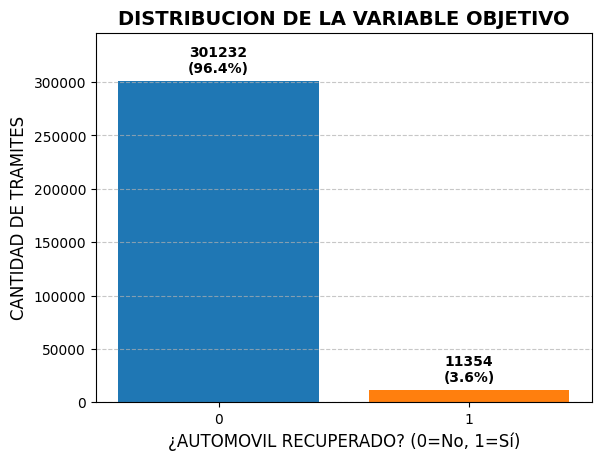

In [ ]:
# CREO EL GRAFICO (con str() en el index para que Matplotlib entienda que son categorías y no números)
barras = plt.bar(conteo_clases.index.astype(str), conteo_clases.values, color=['#1f77b4', '#ff7f0e'])

# AGREGO LAS ETIQUETAS DE TEXTO SOBRE LAS BARRAS
for barra in barras:
    height = barra.get_height()
    porcentaje = (height / total) * 100
    plt.text(barra.get_x() + barra.get_width()/2., height + 5000,
             f'{int(height)}\n({porcentaje:.1f}%)', # Texto: Cantidad y Porcentaje
             ha='center', va='bottom', fontweight='bold')

# CAMBIO LA FUENTE TIPOGRAFICA QUE VIENE POR DEFAULT
plt.title("DISTRIBUCION DE LA VARIABLE OBJETIVO", fontsize=14, fontweight='bold')
plt.xlabel("¿AUTOMOVIL RECUPERADO? (0=No, 1=Sí)", fontsize=12)
plt.ylabel("CANTIDAD DE TRAMITES", fontsize=12)

# AJUSTO LIMITE SUPERIOR (para que las etiquetas no se corten)
plt.ylim(0, max(conteo_clases.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 📝 ***Nota Importante:*** Distribución de la Variable Objetivo 👆
Como se observa en el gráfico el dataset está desbalanceado hay más casos "0" (NO Recuperados) que "1" SI Recuperados. Esto es un punto a considerar a la hora de elegir el modelo para que no haya conclusiones erroneas.

# 🧩 *Creo las Variables Predictoras (Feature Engineering)* 👇

*   **"antiguedad_vehiculo"** → Antigüedad del Vehículo al momento de la denuncia.
*   **"dia_semana_denuncia"** → Día de la Semana en que se hizo la denuncia.







In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
#                   CREO LAS COLUMNAS PREDICTORAS QUE VOY A NECESITAR
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO LA COUMNA DE LA ANTIGUEDAD DEL VEHICULO AL MOMENTO DE LA DENUNCIA

# EXTRAIGO EL AÑO DE LA DELUNCIA Y LE RESTO EL AÑO DEL MODELO
dfcorregido["antiguedad_vehiculo"] = dfcorregido["tramite_fecha"].dt.year - dfcorregido["automotor_anio_modelo"]

# CORROBORO QUE LA COLUMNA TENGA VALORES COHERENTES
print("─"*150)
print('VALORES UNICOS DE LA COLUMNA CREADA: "antiguedad_vehiculo"')
print()
print(dfcorregido["antiguedad_vehiculo"].unique())
print()
print("─"*150)

# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO LA COUMNA DEL DIA DE LA SEMANA EN QUE SE HIZO LA DENUNCIA
# DIA DE LA SEMANA: (0=Lunes, 6=Domingo)

# EXTRAIGO EL DIA DE LA SEMANA EN QUE SE HIZO LA DENUNCIA
dfcorregido["dia_semana_denuncia"] = dfcorregido["tramite_fecha"].dt.dayofweek

# CORROBORO QUE LA COLUMNA TENGA VALORES COHERENTES
print("─"*150)
print('VALORES UNICOS DE LA COLUMNA CREADA: "dia_semana_denuncia" (0=Lunes, 6=Domingo)')
print()
display(sorted(dfcorregido["dia_semana_denuncia"].dropna().unique()))
print()
print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALORES UNICOS DE LA COLUMNA CREADA: "antiguedad_vehiculo"

[ 22  10   8  17  19  12  20  18  49  29  11  24  16  21  31  23  25  33
  14   9  13   2   5   3   0  26   4   6   1   7  15  35  27  28  38  39
  34  32  30  42  51  40  37  43  36  47  48  44  53  57  54  52  41  60
  58  45  46  62  50  56  59  64  55  84  94  61  65 114]

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALORES UNICOS DE LA COLUMNA CREADA: "dia_semana_denuncia" (0=Lunes, 6=Domingo)



[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6)]


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


**Nota:** A fín de evitar que el "Modelo" confunda o haga trampa con la predicción **Elimino** la columna **"tramite_tipo"** de mis columnas predictoras. 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# BORRO LA COLUMNA ORIGINAL "tramite_tipo" DE LAS VARIABLES PREDICTORAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

dfcorregido = dfcorregido.drop(columns=["tramite_tipo"], errors="ignore")

# CORROBORO QUE SE HAYA ELIMINADO LA COLUMNA
print(dfcorregido.info())

<class 'pandas.core.frame.DataFrame'>
Index: 312586 entries, 0 to 312627
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   tramite_fecha                   312586 non-null  datetime64[ns]
 1   fecha_inscripcion_inicial       312586 non-null  datetime64[ns]
 2   registro_seccional_codigo       312586 non-null  int64         
 3   registro_seccional_descripcion  312586 non-null  object        
 4   registro_seccional_provincia    312586 non-null  object        
 5   automotor_origen                312586 non-null  object        
 6   automotor_anio_modelo           312586 non-null  int64         
 7   automotor_tipo_descripcion      312586 non-null  object        
 8   automotor_marca_descripcion     312586 non-null  object        
 9   automotor_modelo_descripcion    312586 non-null  object        
 10  titular_domicilio_provincia     312586 non-null  object      

# ⚙️ *Reviso el Tipo de Columnas que me van quedando* 👇

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# REVISO LOS TIPOS DE VARIABLES
#------------------------------------------------------------------------------------------------------------------------------------------------

# SEPARO LAS COLUMNAS SEGUN SU TIPO DE DATO
columnas_numericas = dfcorregido.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = dfcorregido.select_dtypes(include=["object"]).columns.tolist()

print("─"*150)
print("COLUMNAS NUMERICAS: ")
print(columnas_numericas)
print("─"*150)
print()
print("─"*150)
print("COLUMNAS CATEGORICAS: ")
print(columnas_categoricas)
print("─"*150)
print()

print("─"*150)
print("CANTIDAD DE VALORES UNICOS EN VARIABLES NUMERICAS: ")
print()
print(dfcorregido[columnas_numericas].nunique().sort_values(ascending=False))
print("─"*150)

print()

print("─"*150)
print("CANTIDAD DE VALORES UNICOS EN VARIABLES CATEGORICAS: ")
print()
print(dfcorregido[columnas_categoricas].nunique().sort_values(ascending=False))
print("─"*150)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS NUMERICAS: 
['registro_seccional_codigo', 'automotor_anio_modelo', 'titular_anio_nacimiento', 'titular_edad_tramite', 'recuperado_si_no', 'antiguedad_vehiculo']
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COLUMNAS CATEGORICAS: 
['registro_seccional_descripcion', 'registro_seccional_provincia', 'automotor_origen', 'automotor_tipo_descripcion', 'automotor_marca_descripcion', 'automotor_modelo_descripcion', 'titular_domicilio_provincia', 'titular_genero']
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

# 📊 *Creo algunos graficos para verificar/entender los datos* 👇

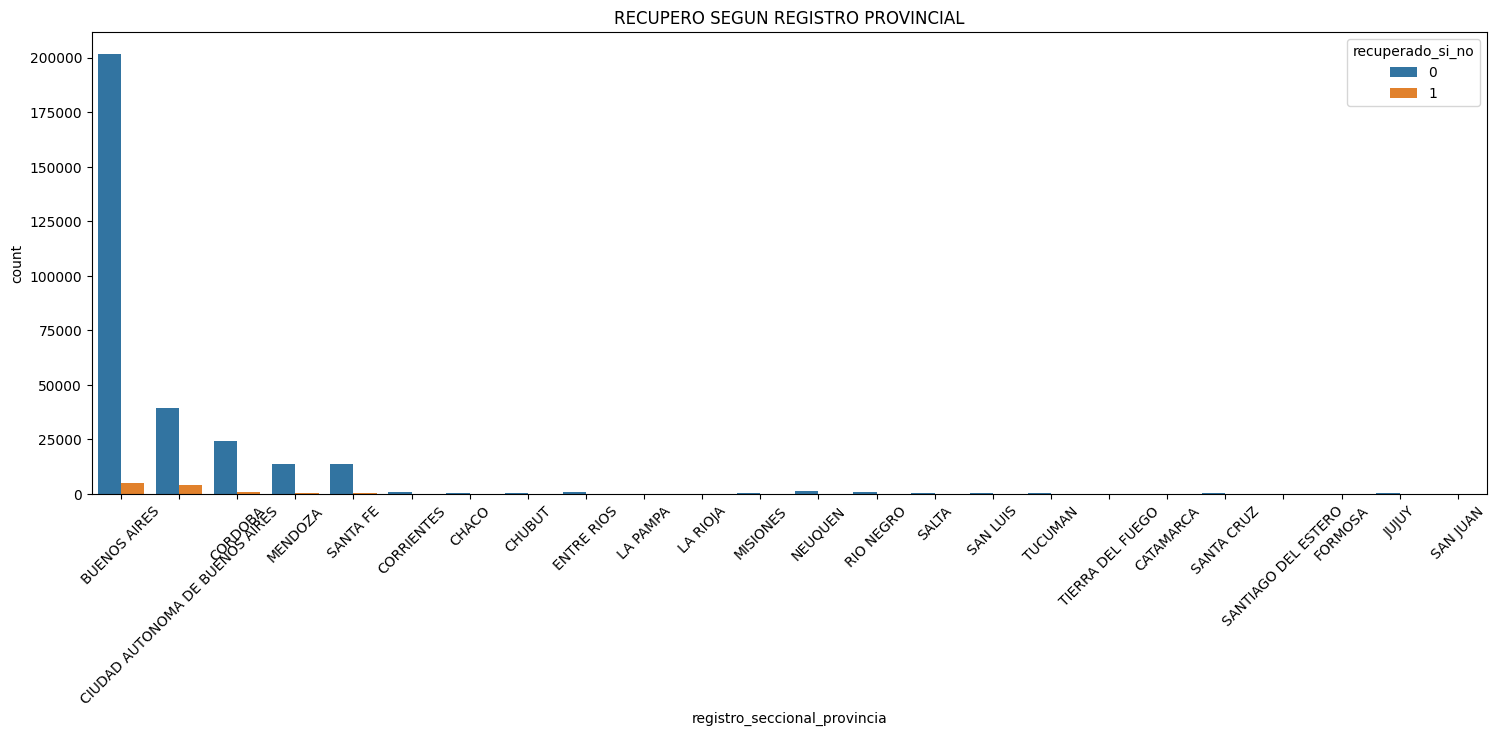

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# RECUPERO SEGUN REGISTRO PROVINCIAL
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(18,6))

sns.countplot(
    data=dfcorregido,
    x="registro_seccional_provincia",
    hue="recuperado_si_no")

plt.xticks(rotation=45)
plt.title("RECUPERO SEGUN REGISTRO PROVINCIAL")
plt.show()


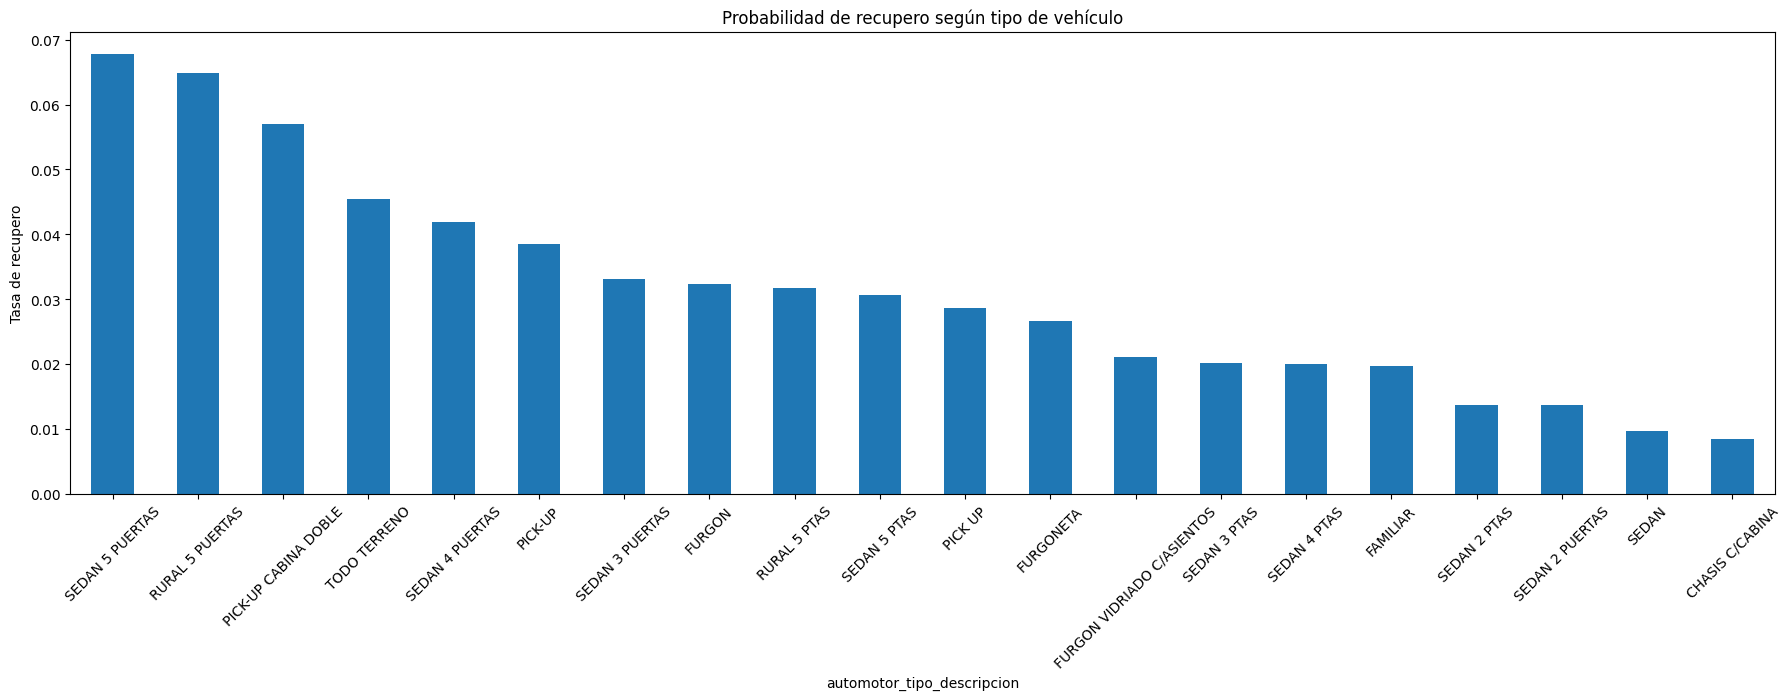

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# PROBABILIDAD DE RECUPERO SEGUN TIPO DE VEHICULO GRAFICO TOP 20 MAS RECUPERADOS
# ------------------------------------------------------------------------------------------------------------------------------------------------
top20 = (
    dfcorregido["automotor_tipo_descripcion"]
    .value_counts()
    .head(20)
    .index
)

tabla = (
    dfcorregido[
        dfcorregido["automotor_tipo_descripcion"].isin(top20)
    ]
    .groupby("automotor_tipo_descripcion")["recuperado_si_no"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(22,6))

tabla.plot(kind="bar")

plt.title("Probabilidad de recupero según tipo de vehículo")
plt.ylabel("Tasa de recupero")
plt.xticks(rotation=45)

plt.show()

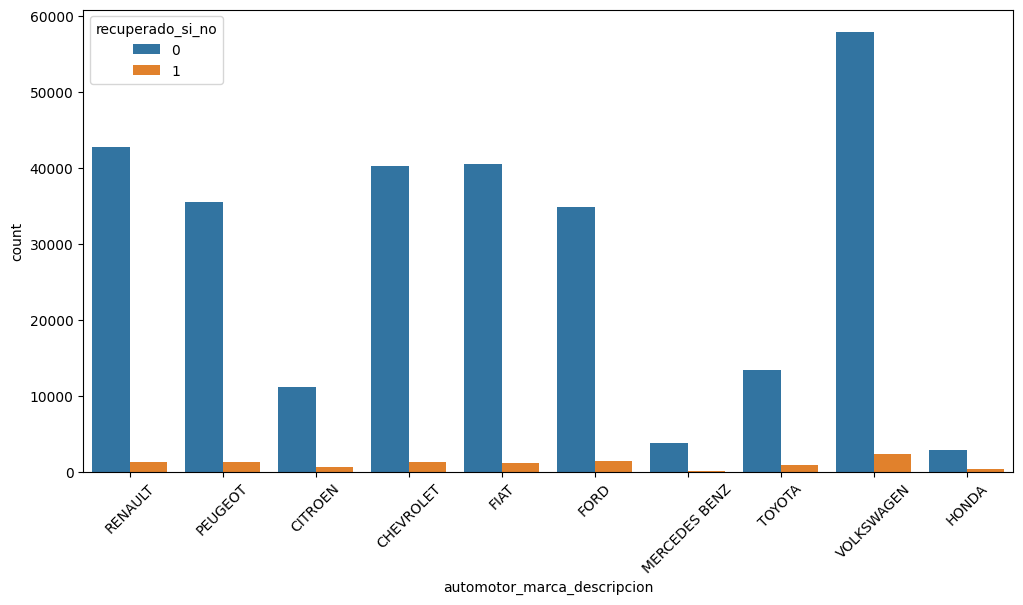

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# RECUPERACION O NO SEGUN 10 MARCAS MAS RECURRENTES  - TOP 10 DE MARCAS MAS RECURRENTES -
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UN TOP TEN DE MARCAS PARA DESPUES GRAFICAR SOLO ESAS
top_marcas = (
    dfcorregido["automotor_marca_descripcion"]
    .value_counts()
    .head(10)
    .index)

df_top = dfcorregido[
    dfcorregido["automotor_marca_descripcion"].isin(top_marcas)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_top,
    x="automotor_marca_descripcion",
    hue="recuperado_si_no")

plt.xticks(rotation=45)
plt.show()


# ⚙️⚡*Aplico el Target Encoding y Label Encoding* 👇

**NOTA:** Utilizé Target Encoding para variables categóricas de alta cardinalidad, ya que técnicas como One-Hot Encoding hubieran generado un número excesivo de columnas.

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# APLICO TARGET ENCODING PARA REDUCIR LA CANTIDAD DE CASOS UNICOS EN LAS COLUMNAS
#------------------------------------------------------------------------------------------------------------------------------------------------

# INSTALO E IMPORTO LIBRERIAS
#!pip install category_encoders
#from category_encoders import TargetEncoder
#from sklearn.preprocessing import LabelEncoder


# 2. TARGET ENCODING para las variables de alta cardinalidad
# Corregido: usamos coma en lugar de punto y coma dentro de la lista
encoder = TargetEncoder(cols=["automotor_modelo_descripcion",
                               "automotor_marca_descripcion",
                               "automotor_tipo_descripcion",
                               "registro_seccional_descripcion"
                              ])

dfcorregido = encoder.fit_transform(dfcorregido, dfcorregido["recuperado_si_no"])

# 3. LABEL ENCODING para variables categóricas con pocos valores
le = LabelEncoder()
columnas_label = ["automotor_origen",
                  "titular_genero",
                  "titular_domicilio_provincia",
                  "registro_seccional_provincia"

                  ]

for col in columnas_label:
    dfcorregido[col] = le.fit_transform(dfcorregido[col].astype(str))

# 4. Verificación de resultados
print("─"*150)
print("PRIMERAS FILAS TRANSFORMADAS:")
print("─"*150)
print(dfcorregido[["automotor_modelo_descripcion", "automotor_marca_descripcion", "titular_genero"]].head())
print("─"*150)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PRIMERAS FILAS TRANSFORMADAS:
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   automotor_modelo_descripcion  automotor_marca_descripcion  titular_genero
0                      0.024447                     0.028989               1
1                      0.030712                     0.034137               2
2                      0.046823                     0.035804               2
3                      0.000002                     0.046966               0
4                      0.022609                     0.031087               0
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# VERIFICO VALORES UNICOS EN VARIABLES NUMERICAS Y CATEGORICAS
#------------------------------------------------------------------------------------------------------------------------------------------------

# DEFINO LAS LISTAS SEGUN EL ESTADO ACTUAL DEL DATAFRAME
columnas_numericas = dfcorregido.select_dtypes(include=['number']).columns
columnas_categoricas = dfcorregido.select_dtypes(include=['object']).columns

print("─"*150)
print("VALORES UNICOS EN VARIABLES NUMÉRICAS (Listas para el modelo):")
print(dfcorregido[columnas_numericas].nunique().sort_values(ascending=False))
print("─"*150)
print()
if len(columnas_categoricas) > 0:
    print("─"*150)
    print("VALORES ÚNICOS EN VARIABLES CATEGÓRICAS (Aún pendientes o para borrar):")
    print("─"*150)
    print()
    print(dfcorregido[columnas_categoricas].nunique().sort_values(ascending=False))
    print("─"*150)
else:
    print("─"*150)
    print("¡LISTO! YA NO QUEDAN VARIABLES CATEGORICAS DE TEXTO")
    print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VALORES UNICOS EN VARIABLES NUMÉRICAS (Listas para el modelo):
automotor_modelo_descripcion      1108
registro_seccional_codigo          844
registro_seccional_descripcion     625
automotor_tipo_descripcion         135
automotor_marca_descripcion         90
titular_anio_nacimiento             90
titular_edad_tramite                83
automotor_anio_modelo               72
antiguedad_vehiculo                 68
titular_domicilio_provincia         24
registro_seccional_provincia        24
dia_semana_denuncia                  7
automotor_origen                     3
titular_genero                       3
recuperado_si_no                     2
dtype: int64
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# BORRO LAS COLUMAS TRANSFORMADAS Y QUE PUEDEN GENERAR RUIDO
#------------------------------------------------------------------------------------------------------------------------------------------------

# COLUMNAS QUE SOBRAN
columnas_a_borrar = [
    "tramite_fecha",
    "fecha_inscripcion_inicial",
    "titular_anio_nacimiento",        # Ya tengo titular_edad_tramite
    "registro_seccional_codigo" ]      # Es un ID que hace referencia a la seccional que tomó la denuncia

#   "registro_seccional_descripcion", # Ya tengo el código o provincia
#   "fecha_denuncia"                  # la borre despues de sacar el día de la semana

# BORRO Y MUESTRO TOTAL DE COLUMNAS FINALES (ignore por si ya las borre antes)
df_final = dfcorregido.drop(columns=columnas_a_borrar, errors="ignore")
print("─"*150)
print(f"¡DATASET LISTO! COLUMNAS FINALES: {len(df_final.columns)}")
print("─"*150)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
¡DATASET LISTO! COLUMNAS FINALES: 13
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# 💾 CAMBIO EL NOMBRE DEL DATASET - LO GUARDO EN COLAB Y LO DESCARGO EN MI PC 👇

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# GENERO EL ARCHIVO FISICO EN COLAB Y LO DESCARGO EN MI PC - EL ARCHIVO SE LLAMA: "df_final.csv"
# ------------------------------------------------------------------------------------------------------------------------------------------------

# CONVIERTO EL DATAFRAME EN UN ARCHIVO FISICO Y LO GUARDO EN COLAB
df_final.to_csv("df_final.csv", index=False)

# DESCARGO EL ARCHIVO PARA VERLO EN MI PC
from google.colab import files
files.download ("df_final.csv")

print("─"*150)
print('✅ ARCHIVO CORREGIDO GUARDADO COMO: "df_final.csv" 💾')
print("─"*150)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✅ ARCHIVO CORREGIDO GUARDADO COMO: "df_final.csv" 💾
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# 📊 *Creo algunos graficos para verificar/entender los datos* 👇

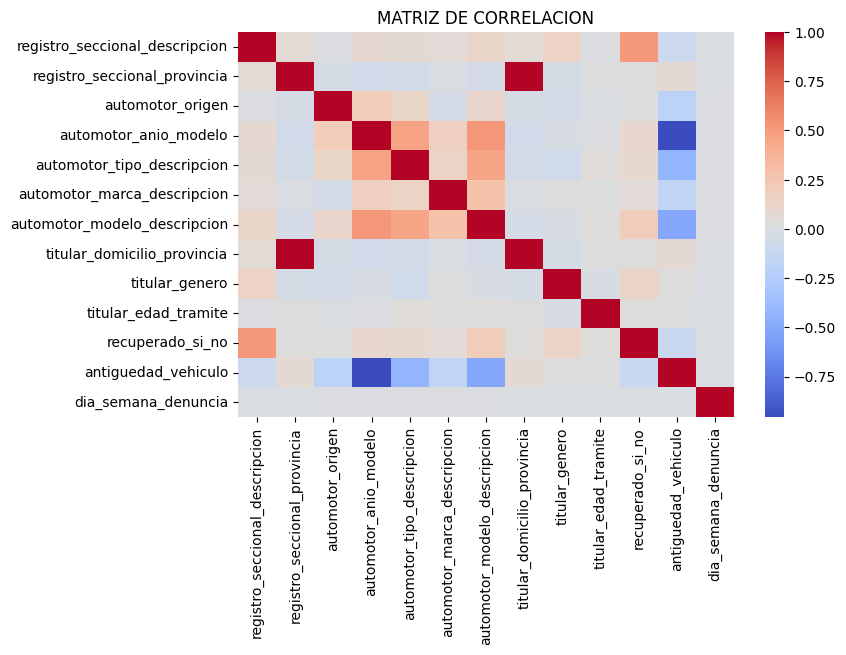

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# MATRIZ DE CORRELACION GENERAL SIN FILTROS
# ------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.heatmap(
    df_final.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False)

plt.title("MATRIZ DE CORRELACION")

plt.show()


In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# DATOS SOLO DE LAS CORRELACIONES DE LA VARIABLE OBJETIVO
# ------------------------------------------------------------------------------------------------------------------------------------------------

correlaciones = (
    df_final.corr(numeric_only=True)["recuperado_si_no"]
    .sort_values(ascending=False))
print(correlaciones)

recuperado_si_no                  1.000000
registro_seccional_descripcion    0.515914
automotor_modelo_descripcion      0.195061
titular_genero                    0.135926
automotor_anio_modelo             0.104106
automotor_tipo_descripcion        0.095843
automotor_marca_descripcion       0.056948
titular_domicilio_provincia       0.033275
registro_seccional_provincia      0.033275
titular_edad_tramite              0.032607
automotor_origen                  0.020666
dia_semana_denuncia              -0.001464
antiguedad_vehiculo              -0.113484
Name: recuperado_si_no, dtype: float64


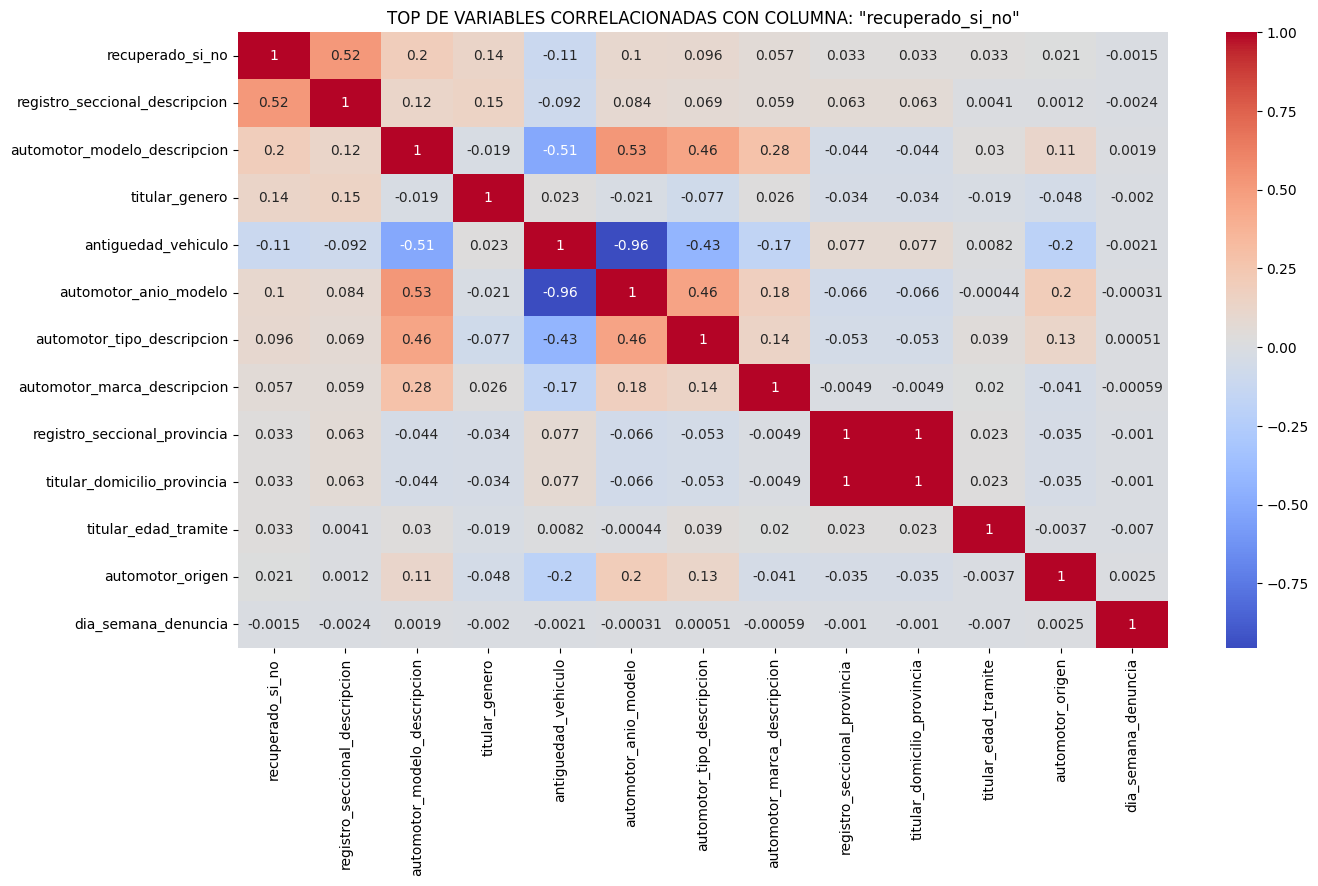

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# MATRIZ DE CORRELACION SOLO CON LAS VARIABLES CON MAS CORRELACION
# ------------------------------------------------------------------------------------------------------------------------------------------------

corr = df_final.corr(numeric_only=True)

top_corr = corr["recuperado_si_no"].abs().sort_values(ascending=False)
top_features = top_corr.head(15).index
plt.figure(figsize=(15,8))

sns.heatmap(
    df_final[top_features].corr(),
    annot=True,
    cmap="coolwarm")

plt.title('TOP DE VARIABLES CORRELACIONADAS CON COLUMNA: "recuperado_si_no"')
plt.show()


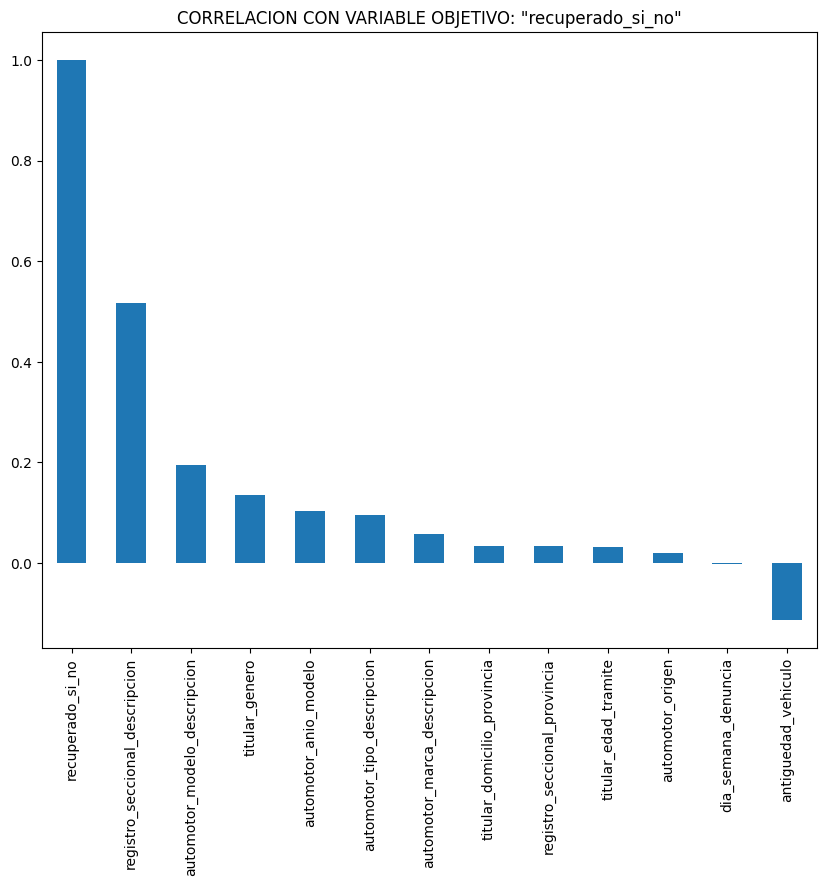

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# MUESTRA DE LA VARIABLE OBJETIVO CON LAS VARIABLES MAS CORRELACIONADAS
# ------------------------------------------------------------------------------------------------------------------------------------------------

correlaciones = (
    df_final.corr(numeric_only=True)["recuperado_si_no"]
    .sort_values(ascending=False))
plt.figure(figsize=(10,8))
correlaciones.plot(kind="bar")
plt.title('CORRELACION CON VARIABLE OBJETIVO: "recuperado_si_no"')
plt.show()

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# DEFINO LA VARIABLE OBJETIVO (y) Y LAS PREDICTORAS (X)
# ------------------------------------------------------------------------------------------------------------------------------------------------

# DEFINO X (todas las columnas menos la que quiero predecir y las que me sobran)
# Incluyo cualquier columna de texto o fecha que haya quedado

columnas_sobrantes = ['recuperado_si_no', 'tramite_fecha', 'fecha_inscripcion_inicial',
                      'registro_seccional_descripcion', 'fecha_denuncia']

X = df_final.drop(columns=columnas_sobrantes, errors='ignore')

# Definimos y (el objetivo)
y = df_final['recuperado_si_no']

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Forma de X: (312586, 11)
Forma de y: (312586,)


# ➗ *División del Dataset* 👇

## Divido los datos para Entrenamiento y Prueba -  80% para Entrenar y 20% para Testear -

¿Por qué agregué stratify=y?

Como mi dataset está desbalanceado (hay muchos más robos que recuperos), existe el riesgo de que por azar, en el set de prueba no queden casi recuperos para evaluar. Stratify obliga a que tanto el grupo de entrenamiento como el de prueba tengan el mismo porcentaje de "1" y "0".

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------------------
# DIVIDO EL DATASET EN ENTRENAMIENTO Y PRUEBA - 80% PARA ENTRENAR Y 20% PARA TESTEAR
# ------------------------------------------------------------------------------------------------------------------------------------------------

# DIVIDO LOS DATOS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,     # 20% para prueba
    random_state=42,    # Para que el resultado sea siempre el mismo al re-ejecutar
    stratify=y          # MUY IMPORTANTE: mantiene la proporción de recuperados en ambos sets
)

print(f"Registros para entrenar: {len(X_train)}")
print(f"Registros para evaluar: {len(X_test)}")


Registros para entrenar: 250068
Registros para evaluar: 62518


----------------------------------- HASTA ACÁ ES LA PREENTREGA -----------------------------------



--------------------------------- ACÁ COMIENZA LA ENTREGA FINAL ---------------------------------


## 📋**NOTA IMPORTANTE:** Pruebo entrenar el modelo con el metodo "Random Forest" que según entiendo es la mejor opción para este tipo de Datasets tan desbalanceados.

# 🤖 ENTRENAMIENTO DEL MODELO  👇

In [ ]:
# ENTRENO AL MODELO CON RANDOMFOREST (por consejo de IA)

#from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import classification_report, confusion_matrix

# CREO EL MODELO (class_weight='balanced' ayuda con el desbalanceo)
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# GENERO EL ENTRENAMIENTO
modelo_rf.fit(X_train, y_train)

# GENERO LA PREDICCION (con los datos que no conoce)
y_pred = modelo_rf.predict(X_test)

# EVALUO LOS RESULTADOS
print()
print("─"*150)
print("RESULTADOS DEL MODELO: CLASSIFICATION REPORT")
print("─"*150)
print()
print(classification_report(y_test, y_pred))


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RESULTADOS DEL MODELO:
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     60247
           1       0.68      0.29      0.40      2271

    accuracy                           0.97     62518
   macro avg       0.83      0.64      0.69     62518
weighted avg       0.96      0.97      0.96     62518



# 📌 *Interpretación de los Resultados: "Classification Report"* 👆

El modelo obtuvo una exactitud (accuracy) del 97%, lo que indica un buen desempeño general sobre el conjunto de prueba. Sin embargo, debido al desbalance entre las clases, esta métrica debe interpretarse junto con Precision, Recall y F1-score.

Para la clase 0, el modelo presenta un rendimiento excelente, con una precisión del 97%, un recall del 99% y un F1-score del 98%, lo que demuestra que identifica correctamente la gran mayoría de estos registros.

En cambio, para la clase 1, el modelo alcanza una precisión del 68%, pero un recall de solo 29%, indicando que, aunque las predicciones positivas suelen ser correctas, el modelo deja sin identificar una proporción importante de los casos positivos reales. Esto también se refleja en un F1-score de 0,40, considerablemente inferior al obtenido para la clase mayoritaria.

En conjunto, estos resultados sugieren que el modelo presenta un buen desempeño global, pero aún tiene dificultades para detectar la clase minoritaria, probablemente debido al desbalance existente en el conjunto de datos. Como trabajo futuro, podrían evaluarse técnicas de balanceo de clases, como SMOTE, ajuste de pesos (class_weight) o la optimización del umbral de decisión, con el objetivo de mejorar la capacidad de detección de los casos positivos.

Dado que el objetivo del proyecto fue aplicar el flujo completo de un proceso de Machine Learning, se priorizó la construcción e interpretación del modelo. No obstante, una línea de mejora futura consistiría en optimizar el rendimiento sobre la clase minoritaria mediante técnicas específicas para datos desbalanceados.

# 📊 *Matriz de Confusión* 👇





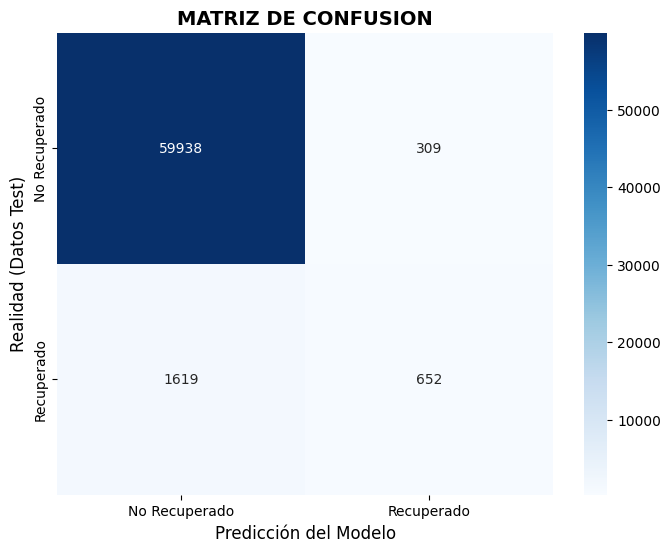

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# MATRIZ DE CONFUSION
#------------------------------------------------------------------------------------------------------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# CALCULO LA MATRIZ
cm = confusion_matrix(y_test, y_pred)

# GENERO EL GRAFICO DE LA MATRIZ
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Recuperado', 'Recuperado'],
            yticklabels=['No Recuperado', 'Recuperado'])

plt.title('MATRIZ DE CONFUSION', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Datos Test)', fontsize=12)
plt.show()

# 📌*Interpretación de la Matriz de Confusión👆*

El modelo es excelente detectando los No Recuperados (casilla superior izquierda).

Sin embargo, vemos que todavía le cuesta un poco identificar los recuperos reales sin equivocarse (hay una cantidad importante de falsos positivos). Esto es normal en datasets tan desbalanceados, pero el modelo está haciendo un esfuerzo mucho mayor que el azar.

# *Reporte de la Curva ROC y AUC 👇*

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# OBTENGO LAS PROBABILIDADES DEL MODELO
#------------------------------------------------------------------------------------------------------------------------------------------------

# Probabilidad de pertenecer a la clase positiva (1)
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

#------------------------------------------------------------------------------------------------------------------------------------------------
# CALCULO LA CURVA ROC Y EL AUC
#------------------------------------------------------------------------------------------------------------------------------------------------
# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el área bajo la curva
auc = roc_auc_score(y_test, y_prob)

print(f"AUC = {auc:.4f}")

AUC = 0.8222


#📊 *Gráfico de "Curva ROC"* 👇

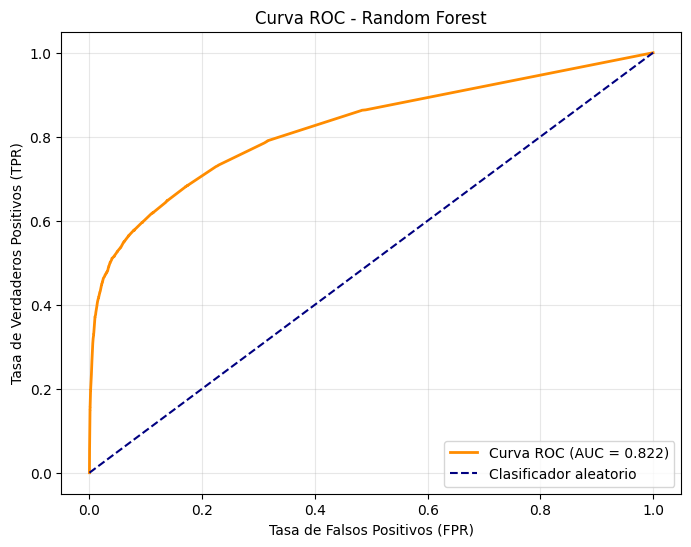

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# GRAFICO LA CURVA ROC
#------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         color="darkorange",
         linewidth=2,
         label=f"Curva ROC (AUC = {auc:.3f})")

plt.plot([0,1], [0,1],
         linestyle="--",
         color="navy",
         label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Random Forest")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

# 📌 *Interpretación de la Curva ROC 👆*

La Curva ROC permite evaluar la capacidad del modelo para distinguir entre ambas clases considerando distintos umbrales de decisión. En este caso, el modelo obtuvo un Área Bajo la Curva (AUC) de 0.822, lo que indica una buena capacidad discriminatoria, ya que el valor es significativamente superior a
0.5, correspondiente a un clasificador aleatorio.

Este resultado sugiere que el modelo logra ordenar correctamente la mayoría de los casos positivos y negativos según su probabilidad de pertenecer a cada clase. Sin embargo, tal como se observó en el Classification Report, el modelo presenta un recall relativamente bajo para la clase minoritaria, por lo que aún deja sin identificar una parte importante de los casos positivos. Esto indica que, si bien el modelo discrimina adecuadamente entre ambas clases, podrían aplicarse técnicas adicionales para mejorar la detección de la clase minoritaria, como el ajuste del umbral de decisión, el balanceo de clases o la optimización de hiperparámetros.


# *Reporte de Importancia de las Variables 👇*

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# IMPORTANCIA DE VARIABLES
#------------------------------------------------------------------------------------------------------------------------------------------------

# CREO UN DATAFRAME CON LA IMPORTANCIA DE CADA VARIABLE
feature_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

# ORDENO DE MAYOR A MENOR
feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)

# MUESTRO SOLO LOS TOP 20
top20 = feature_importance.head(20)

display(top20)

,Variable,Importancia
5,automotor_modelo_descripcion,0.231710
8,titular_edad_tramite,0.171897
7,titular_genero,0.131557
9,antiguedad_vehiculo,0.111082
2,automotor_anio_modelo,0.092407
3,automotor_tipo_descripcion,0.056820
4,automotor_marca_descripcion,0.054480
10,dia_semana_denuncia,0.053668
6,titular_domicilio_provincia,0.037846
0,registro_seccional_provincia,0.037500


#📊 *Gráfico de "Importancia de las Variables"* 👇

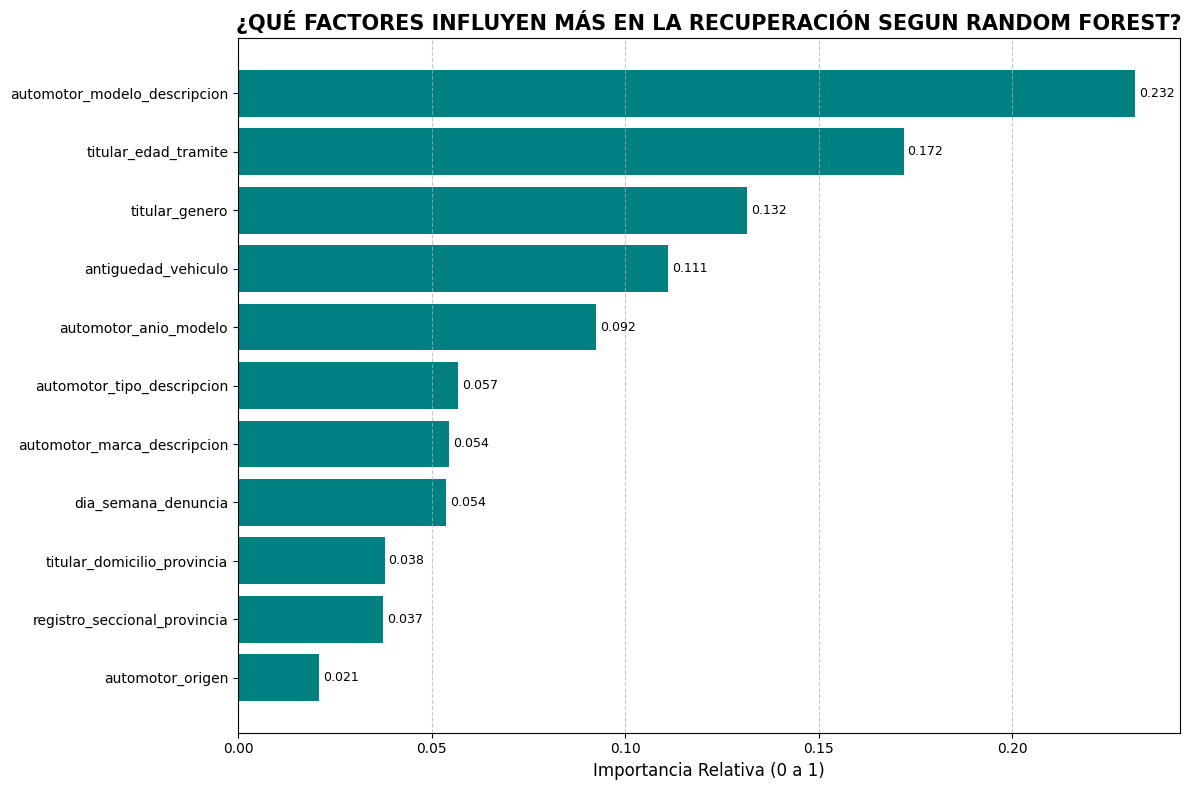

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------
# GENERO UN GRAFICO PARA EVALUAR VISUALMENTE EL MODELO
#------------------------------------------------------------------------------------------------------------------------------------------------

# OBTENGO LAS IMPORTANCIAS DEL MODELO
importancias = modelo_rf.feature_importances_
nombres_columnas = X.columns

# OREDENO DE MAYOR A MENOR
indices = np.argsort(importancias)

plt.figure(figsize=(12, 8))
plt.title("¿QUÉ FACTORES INFLUYEN MÁS EN LA RECUPERACIÓN SEGUN RANDOM FOREST?", fontsize=15, fontweight='bold')

# CREO EL GRAFICO DE BARRAS HORIZONTALES
plt.barh(range(len(indices)), importancias[indices], color='teal', align='center')

# NOMBRE DE COLUMNAS Y EJE VERTICAL
plt.yticks(range(len(indices)), [nombres_columnas[i] for i in indices])
plt.xlabel('Importancia Relativa (0 a 1)', fontsize=12)

# CUADRICULA
plt.grid(axis='x', linestyle='--', alpha=0.7)

# VALOR SOBRE CADA BARRA
for index, value in enumerate(top20["Importancia"][::-1]):
    plt.text(value + 0.001,
             index,
             f"{value:.3f}",
             va="center",
             fontsize=9)


plt.tight_layout()
plt.show()

# 📌 *Interpretación de la importancia de variables* 👆

El algoritmo Random Forest permite estimar la importancia relativa de cada variable en el proceso de clasificación, indicando cuáles contribuyeron en mayor medida a la construcción de los árboles de decisión.

El gráfico muestra las variables con mayor importancia, observándose que el modelo basa principalmente sus predicciones en un conjunto reducido de atributos, mientras que el resto aporta una influencia menor. Este análisis resulta útil para interpretar el comportamiento del modelo y comprender qué características tienen mayor impacto en la clasificación realizada.

En síntesis: La variable "Automotor Modelo Descripción" fue la que mayor influencia tuvo en las predicciones del modelo, seguida por "Titular Edad Trámite" y "Titular Genero". Esto sugiere que estas características contienen la mayor parte de la información utilizada por el algoritmo para distinguir entre ambas clases.

# **💡 CONCLUSION FINAL DEL PROYECTO 💡**|🏁

El presente proyecto permitió desarrollar un modelo de Machine Learning siguiendo todas las etapas del proceso analítico: integración y limpieza de datos, análisis exploratorio, transformación de variables, selección de atributos, entrenamiento y evaluación del modelo.

Para ello se unificaron 99 archivos históricos correspondientes al período 2018–2026, publicados por la Dirección Nacional de los Registros Nacionales de la Propiedad del Automotor (DNRPA), construyéndose un dataset consolidado que permitió entrenar un modelo de clasificación basado en Random Forest.

Durante la evaluación, el modelo obtuvo una exactitud (Accuracy) del 97% y un Área Bajo la Curva ROC (AUC) de 0.822, lo que evidencia una buena capacidad para diferenciar entre las dos clases analizadas. No obstante, el análisis del Classification Report mostró un comportamiento diferente entre ambas clases: mientras que la clase mayoritaria fue clasificada con un desempeño muy elevado (F1-score de 0.98), la clase minoritaria presentó un Recall del 29% y un F1-score de 0.40. Este resultado indica que, aunque el modelo identifica correctamente la mayoría de los registros generales, todavía presenta dificultades para detectar todos los casos pertenecientes a la clase minoritaria, una situación esperable debido al fuerte desbalance existente en el conjunto de datos.

Con el objetivo de reducir el efecto de dicho desbalance, se entrenó el modelo utilizando class_weight='balanced', estrategia que permitió mejorar el tratamiento de la clase minoritaria sin modificar la distribución original de los datos. Como posibles líneas de mejora, podrían evaluarse técnicas adicionales como SMOTE, optimización de hiperparámetros o ajuste del umbral de decisión para incrementar la sensibilidad del modelo.

El análisis de importancia de variables permitió identificar que los atributos relacionados con las características del vehículo y el contexto geográfico concentran la mayor capacidad explicativa del modelo, aportando además un grado importante de interpretabilidad sobre las decisiones tomadas por el algoritmo.

Es importante destacar que, debido a las limitaciones del dataset de origen, el modelo no tiene un alcance predictivo temporal. La base de datos no dispone de un identificador único que permita vincular una denuncia con su posterior recupero, por lo que el modelo no estima la probabilidad futura de recuperar un vehículo robado, sino que clasifica registros existentes como pertenecientes a la categoría "Denuncia" o "Recupero" a partir de los patrones presentes en las variables disponibles.

En conjunto, los resultados obtenidos demuestran la utilidad de las técnicas de Machine Learning para identificar patrones complejos dentro de grandes volúmenes de información y evidencian cómo variables relacionadas con el vehículo y su contexto aportan información relevante para la clasificación de los registros. Asimismo, el trabajo deja establecida una base metodológica sólida sobre la cual podrían desarrollarse, en el futuro, modelos predictivos de mayor alcance si se dispusiera de información que permitiera seguir la evolución de cada vehículo desde la denuncia hasta su eventual recuperación.